# BoatPhone — the hydrophone (sound) pipeline, start to finish

**What you are reading.** This is the single reproducible record of the *acoustic* half of
the BoatPhone project: every step from "I have no account and no data" to "here are the
figures and the numbers." It is written to be run top to bottom by somebody who has never
seen this repository before.

There is a companion notebook for the *optical* (satellite imagery) half. It does not exist
yet. Wherever this pipeline needs something from that side, you will see a flag like this:

> 🛰️ **OPTICAL HANDOFF — [short name]**
> what is needed, who produces it, and what this notebook does in the meantime.

Search the notebook for `OPTICAL HANDOFF` to find them all at once.

---

## The project in one paragraph

Satellites see every boat in a patch of ocean, but only for the fraction of a second the
satellite is overhead. A hydrophone (an underwater microphone) hears boats continuously, day
and night, but cannot tell you how many there are. BoatPhone uses each instrument to fix the
other's blind spot: satellite images give us *ground truth* — "there were three boats here at
this exact instant" — for a handful of moments, and we use those moments to check whether a
number computed from the sound agrees. If it does, the sound can then be used to estimate boat
traffic *continuously*, including for small recreational boats, which carry no radio
transponder and are invisible to every conventional vessel-tracking method.

The listening station is **Folger Deep**, a cabled observatory in Barkley Sound on the west
coast of Vancouver Island, operated by **Ocean Networks Canada (ONC)**.

## What this acoustic pipeline actually achieves

1. It works out **when the hydrophone was recording** over six summers (2020–2025), so that
   nobody wastes money ordering a satellite image for a moment when there is no sound to
   compare it against.
2. It **downloads** the sound data for the short windows around satellite passes — about
   27,000 five-minute files.
3. It turns each file into a **loudness-versus-time trace in a chosen frequency band**, using
   one shared reader so that every notebook in the project measures the same thing.
4. It **counts boat passages** in that trace, and compares the count against boats counted by
   eye in the matching satellite images.
5. It produces the **figures**: the long-term spectrogram, the loudness distribution, seasonal
   spectra, and one review sheet per satellite pass.

## What it does *not* establish — read this before quoting a number

- **The levels are not calibrated.** ONC's product owner has confirmed that the `.fft.gz`
  files are a proprietary Ocean Sonics format that is "essentially uncalibrated," with
  undocumented filtering. Everything here is in the product's own integer scale, which we
  name `counts` at every boundary. **It is never decibels re 1 µPa.** A matched pair of files
  measures roughly 0.52 counts per dB *with curvature*, so no fixed conversion exists.
- **The vessel counter is a proof of concept, not a validated model.** It was chosen from a
  pre-declared field of 32 candidates and scored against only 29 labelled moments, six of
  which contain no boats at all.
- **We have not yet shown that the boats we hear are the boats the satellite saw.** Shifting
  the listening window an hour away from the satellite pass gives 37 passages against 42 at
  the pass itself. We count passages well; we have not shown they are *those* passages.

Those three sentences are the honest summary. The rest of this notebook shows the work.

---
# 0. How to run this notebook

**Heavy steps are switched off by default.** Downloading 27,000 files takes hours and about
7 GB of disk; the whole-corpus figure pass takes tens of minutes. Every such step is wrapped
so that it *prints the exact command* instead of running it, unless you set `RUN_HEAVY = True`
in the setup cell below.

Cheap steps — reading one file, plotting one window, running the self-checks — run for real.

**Where things live.** Two rules, and they are the reason the code is arranged the way it is:

| Directory | Rule |
|---|---|
| `boatphone/` | The **library**. Shared constants and functions. Import from here. Defines no behaviour you run directly. |
| `scripts/` | The **entry points**. Runnable programs. They import from `boatphone/` and define nothing shared themselves. |
| `data/` | **Immutable.** Never edit or delete a downloaded file. Anything computed goes to `data/derived/`. |

The reason for the first rule is worth stating: if the satellite side defined the study window
in one file and the sound side defined it in another, the eventual join between them would
quietly match two *different* windows and produce a wrong answer instead of an error.

In [1]:
# --- Setup. Run this first. ---------------------------------------------------
# RUN_HEAVY controls whether the long-running acquisition and figure steps actually
# execute. Leave it False on a first read-through: every heavy cell will print the
# command it would have run, so you can see the whole pipeline in a minute.
RUN_HEAVY = False

import os, pathlib, subprocess, sys, textwrap

# REPO_ROOT is the top of the checkout. This notebook lives in final_notebooks/,
# so the repo root is one directory up.
REPO_ROOT = pathlib.Path.cwd()
if REPO_ROOT.name == "final_notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))          # so `import boatphone` works
os.chdir(REPO_ROOT)                          # so every relative path below is repo-relative

NOTEBOOK_DIR = REPO_ROOT / "final_notebooks"
print("repository root:", REPO_ROOT)


# --- Clickable links to output folders and files ------------------------------
# Links in a notebook output are resolved relative to the NOTEBOOK's own location
# (final_notebooks/), not to the working directory, so every href needs a "../".
# That is what rel_to_notebook() does. The absolute path is printed alongside every
# link as well, so these cells stay usable from a plain file browser, from a
# terminal, or from a rendered copy of this notebook where links do not work.
from IPython.display import HTML, Image, display


def rel_to_notebook(path):
    '''Path as the notebook's own HTML output needs to see it (e.g. ../data/...).'''
    return os.path.relpath(pathlib.Path(path).resolve(), NOTEBOOK_DIR)


def link(path, label=None):
    '''One clickable link. A directory opens in the JupyterLab file browser.'''
    path = pathlib.Path(path)
    return f'<a href="{rel_to_notebook(path)}" target="_blank">{label or path.name}</a>'


def show_folder(path, label=None):
    '''A clickable folder link plus its absolute path, for copy-paste.'''
    path = pathlib.Path(path)
    display(HTML(f'&#128193; {link(path, label or str(path))}'))
    print("   absolute path:", path.resolve())


def run_script(command, heavy=True, timeout=None):
    '''Run one of the programs in scripts/ and show its output.

    `command` is a list of arguments, e.g. ["scripts/run_b5_gate.py", "--max-windows", "3"].
    If `heavy` is True and RUN_HEAVY is False, the command is printed and NOT run --
    that is how this notebook stays readable without a 6-hour download.
    '''
    argv = [sys.executable] + [str(a) for a in command]
    pretty = "python3 " + " ".join(str(a) for a in command)
    if heavy and not RUN_HEAVY:
        print("SKIPPED (set RUN_HEAVY = True to run this):\n    " + pretty)
        return None
    print("running:\n    " + pretty + "\n" + "-" * 72)
    result = subprocess.run(argv, cwd=REPO_ROOT, timeout=timeout,
                            capture_output=True, text=True)
    print(result.stdout[-8000:])
    if result.returncode != 0:
        # Errors surface. We never swallow a failure and carry on with a plausible number.
        print("STDERR:\n" + result.stderr[-4000:])
        raise RuntimeError(f"{pretty} exited {result.returncode}")
    return result.stdout

repository root: /home/jovyan/ohw26_proj_BoatPhone


---
# 1. Getting an ONC access token, and putting it in a `.env` file

The hydrophone data is free, but you need an account to download it.

### 1.1 Register with Ocean Networks Canada

1. Go to **<https://data.oceannetworks.ca>** and create an account (free).
2. Log in, click your name at the top right, and choose **Profile**.
3. Open the **Web Services API** tab. It shows a long random string — that is your **API
   token**.
4. Copy it. Treat it like a password: it is tied to your account, and anyone who has it can
   make requests as you.

### 1.2 Put the token in a `.env` file

A `.env` file is a plain text file of `NAME=value` lines, sitting at the top of the
repository. It is listed in `.gitignore`, so it can never be committed by accident.

Copy the template and edit it:

```bash
cd <your checkout of ohw26_proj_BoatPhone>
cp .env.example .env
# then open .env in any editor and replace the placeholder:
#   ONC_TOKEN=your-onc-token-here
```

The finished file is exactly one meaningful line:

```
ONC_TOKEN=1a2b3c4d-....-your-real-token
```

### Three things worth knowing about how the token is read

- **The shell wins.** If `ONC_TOKEN` is exported in your environment, it overrides the `.env`
  file. A stale checked-out file can therefore never quietly shadow the credential you
  deliberately supplied.
- **No token value is ever printed.** Errors from `boatphone/credentials.py` name the
  *variable*, the *file* and the *line number* — never the value. Separately, every call into
  ONC's client is wrapped by `boatphone/onc_client.py` so that a failed request cannot print
  its own URL (which contains `&token=...`) into a notebook cell.
- **We do not use `python-dotenv`.** It is not installed on the shared JupyterHub, and adding
  a dependency that a teammate does not have makes the analysis non-reproducible. The parser
  in `boatphone/credentials.py` is about 25 lines of standard library.

The cell below checks whether your token is visible **without ever showing it**.

In [2]:
from boatphone import credentials, paths

env_file = paths.REPO_ROOT / ".env"
print(".env present:", env_file.exists(), "at", env_file)

try:
    token = credentials.get_onc_token()
    print(f"ONC_TOKEN resolved: yes  (length {len(token)} characters; value never printed)")
    HAVE_TOKEN = True
except Exception as exc:
    # A missing token is not a crash -- it just means the download steps cannot run.
    # Everything in this notebook that reads already-downloaded files still works.
    print("ONC_TOKEN resolved: NO")
    print("  reason:", type(exc).__name__, str(exc)[:300])
    print("  -> sections 3 (download) cannot run; every later section reads from disk and can.")
    HAVE_TOKEN = False

.env present: True at /home/jovyan/ohw26_proj_BoatPhone/.env
ONC_TOKEN resolved: yes  (length 36 characters; value never printed)


---
# 2. The shared vocabulary: `boatphone/config.py` and `boatphone/paths.py`

Before any data moves, it is worth seeing the constants, because almost every mistake this
project could make is a disagreement about one of them.

**`boatphone/config.py`** holds every number with physical meaning: the study window, which
months count as "the season", the device code, the shape of a data file, the frequency bands,
the ±15-minute matching window. **`boatphone/paths.py`** holds every directory.

Import them. Do not retype the values into a notebook — two definitions of the same window is
the single most likely way this project produces a confident wrong answer.

### The time convention, stated once

**Everything is UTC.** Every timestamp variable carries its frame in its name: `t_utc_s` means
"absolute seconds since the UTC epoch", never "seconds since the start of this file". A bare
`0.0, 0.25, 0.5, ...` array wearing the name `t_utc_s` would produce a clean-looking
correlation with nothing behind it, which is the most expensive bug available to us.

There is exactly one place a local time appears: the satellite overpass window is expressed in
`America/Vancouver` calendar time, because that is how an overpass schedule is written. It is
converted to UTC exactly once, in `boatphone/acquire.py`, and the UTC offset is **looked up
per date** rather than hardcoded — Vancouver is UTC−8 in winter and UTC−7 in summer, and a
fixed offset would silently mis-slice every window on one side of the changeover.

In [3]:
from boatphone import config

print("STUDY WINDOW AND SITE")
print(f"  device code                 {config.DEVICE_CODE}       (the specific hydrophone)")
print(f"  in-season months (UTC)      {config.SEASON_MONTHS_UTC}   (May-September)")
print(f"  corpus years pulled         {config.CORPUS_PULL_START_YEAR}-{config.CORPUS_PULL_END_YEAR}")
print(f"  study start (UTC)           {config.STUDY_START_UTC:%Y-%m-%d}"
      "   <- validity date of the pre-deployment calibration file;")
print( "                                        earlier deployments are DIFFERENT devices")
print()
print("SHAPE OF ONE .fft.gz FILE")
print(f"  frames x frequency bins     {config.FFT_N_FRAMES} x {config.FFT_N_BINS}")
print(f"  seconds per frame           {config.FFT_FRAME_SECONDS}   -> file covers {config.FFT_FILE_SECONDS} s = 5 min")
print(f"  width of one bin            {config.FFT_BIN_WIDTH_HZ} Hz")
print(f"  lowest usable frequency     {config.FFT_LOWEST_REPRESENTABLE_HZ} Hz  (bin 0 is a structural zero)")
print(f"  level unit                  {config.FFT_LEVEL_UNIT}")
print()
print("FREQUENCY BANDS  (these are BANDS, not boat classes -- see section 9)")
print(f"  small_craft   {config.FFT_B5_SMALL_CRAFT_BAND_HZ} Hz   detection band")
print(f"  ship_proxy    {config.FFT_B5_SHIP_PROXY_BAND_HZ} Hz   detection band")
print(f"  rain          {config.FFT_RAIN_BAND_HZ} Hz  diagnostic")
print(f"  control       {config.FFT_CONTROL_BAND_HZ} Hz diagnostic")
print()
print("MATCHING")
print(f"  half-window around a satellite pass   +/- {config.OVERPASS_MATCH_HALF_WINDOW_S/60:.0f} min")

STUDY WINDOW AND SITE
  device code                 ICLISTENHF1266       (the specific hydrophone)
  in-season months (UTC)      (5, 6, 7, 8, 9)   (May-September)
  corpus years pulled         2020-2025
  study start (UTC)           2020-02-18   <- validity date of the pre-deployment calibration file;
                                        earlier deployments are DIFFERENT devices

SHAPE OF ONE .fft.gz FILE
  frames x frequency bins     1200 x 512
  seconds per frame           0.25   -> file covers 300 s = 5 min
  width of one bin            250.0 Hz
  lowest usable frequency     250.0 Hz  (bin 0 is a structural zero)
  level unit                  product counts (uncalibrated; NOT decibels)

FREQUENCY BANDS  (these are BANDS, not boat classes -- see section 9)
  small_craft   (1000.0, 10000.0) Hz   detection band
  ship_proxy    (250.0, 1000.0) Hz   detection band
  rain          (13000.0, 25000.0) Hz  diagnostic
  control       (51250.0, 102000.0) Hz diagnostic

MATCHING
  half-windo

In [4]:
from boatphone import paths

for name in ["REPO_ROOT", "DATA_DIR", "ONC_OVERPASS_CORPUS_DIR", "ONC_LABELLED_WINDOW_DIR",
             "SAMPLE_DIR", "DERIVED_DIR"]:
    p = getattr(paths, name)
    mark = "exists" if p.exists() else "ABSENT"
    print(f"{name:28s} {mark:7s} {p}")

REPO_ROOT                    exists  /home/jovyan/ohw26_proj_BoatPhone
DATA_DIR                     exists  /home/jovyan/ohw26_proj_BoatPhone/data
ONC_OVERPASS_CORPUS_DIR      exists  /home/jovyan/ohw26_proj_BoatPhone/data/raw/onc/overpass_window_corpus
ONC_LABELLED_WINDOW_DIR      exists  /home/jovyan/ohw26_proj_BoatPhone/data/raw/onc/labelled_window_topup
SAMPLE_DIR                   exists  /home/jovyan/ohw26_proj_BoatPhone/data/Folger Deep Hydrophone Data Sample
DERIVED_DIR                  exists  /home/jovyan/ohw26_proj_BoatPhone/data/derived


### Everything this pipeline has already produced — a directory index

The cell below lists every output folder currently on disk **as clickable links**, newest run
last. Runs are never overwritten: each program writes a fresh timestamped directory with a
`provenance.json` beside its results, so an old figure and the numbers that made it stay
together. Click a folder to open it in the JupyterLab file browser; the absolute path is
printed underneath each one for use from a terminal.

In [5]:
# A jump-off point: every derived output folder, linked, with what is in it.
for label, folder in [
    ("uptime calendar + manifests", paths.DERIVED_DIR),
    ("population figures (whole corpus)", paths.DERIVED_DIR / "population"),
    ("review sheets (one folder per satellite pass)", paths.DERIVED_DIR / "review"),
    ("event / vessel-count tables", paths.DERIVED_DIR / "events"),
    ("downloaded sound -- bulk corpus", paths.ONC_OVERPASS_CORPUS_DIR),
    ("downloaded sound -- targeted top-up", paths.ONC_LABELLED_WINDOW_DIR),
    ("vessel labels (tracked in git)", paths.DATA_DIR / "labels"),
]:
    if not folder.exists():
        print(f"ABSENT  {label}: {folder}")
        continue
    subdirs = sorted(d for d in folder.glob("*") if d.is_dir())
    n_files = sum(1 for f in folder.iterdir() if f.is_file())
    display(HTML(f"&#128193; <b>{label}</b> &mdash; {link(folder, str(folder))}"))
    print(f"   absolute path: {folder.resolve()}")
    print(f"   {len(subdirs)} sub-folder(s), {n_files} file(s) at the top level")
    # Timestamped run directories, most recent last. Not for the two download zones,
    # which hold tens of thousands of files rather than runs.
    if subdirs and folder.name in ("population", "review", "events"):
        display(HTML("   runs: " + " &middot; ".join(link(d, d.name) for d in subdirs)))
    print()

   absolute path: /home/jovyan/ohw26_proj_BoatPhone/data/derived
   4 sub-folder(s), 5 file(s) at the top level



   absolute path: /home/jovyan/ohw26_proj_BoatPhone/data/derived/population
   1 sub-folder(s), 0 file(s) at the top level


   absolute path: /home/jovyan/ohw26_proj_BoatPhone/data/derived/review
   4 sub-folder(s), 0 file(s) at the top level


   absolute path: /home/jovyan/ohw26_proj_BoatPhone/data/derived/events
   11 sub-folder(s), 0 file(s) at the top level


   absolute path: /home/jovyan/ohw26_proj_BoatPhone/data/raw/onc/overpass_window_corpus
   0 sub-folder(s), 53512 file(s) at the top level



   absolute path: /home/jovyan/ohw26_proj_BoatPhone/data/raw/onc/labelled_window_topup
   0 sub-folder(s), 403 file(s) at the top level



   absolute path: /home/jovyan/ohw26_proj_BoatPhone/data/labels
   0 sub-folder(s), 2 file(s) at the top level



### Why the frequency floor of 250 Hz is *not* a problem for us

The product cannot represent anything below 250 Hz. That sounds fatal for vessel detection
until you ask which vessels. Large ships have their most diagnostic tones at 10–100 Hz, well
below the floor. **Small planing hulls — exactly the recreational boats this project is about —
peak at roughly 1–10 kHz**, comfortably inside it. The floor costs us large-vessel detection,
not small-craft detection. That is why the main detection band is 1–10 kHz.

---
# 3. Step one — when was the hydrophone actually recording?

**Purpose.** Satellite images cost money. Before anyone orders one, we need to know which
dates have sound to compare against. This step asks ONC's archive *what files exist* for our
device across the whole study period and writes a calendar with one row per five-minute slot.

**Program:** `scripts/build_uptime_calendar.py`
**Outputs** (into `data/derived/`):

| File | Contents |
|---|---|
| `hydrophone_uptime.csv` | one row per in-season 5-minute UTC slot: available or not |
| `deployments.csv` | when the instrument was in the water, as half-open `[start, end)` intervals |
| `hydrophone_uptime.provenance.json` | what produced the numbers, and from what |

**The headline result:** across the six deployed summers 2020–2025, availability is **97.05%**.

**Two caveats that must travel with that number.**

1. *It is an upper bound.* A slot counts as available if ONC *lists* a file overlapping it,
   and each file is modelled as covering its full 300 seconds. Dropouts shorter than about ten
   minutes therefore cannot appear at all. The provenance file records `source = "listing"`
   precisely so that a later, download-refined calendar is distinguishable by inspection
   rather than by memory. Where the download and the listing disagree, **the download wins**.
2. *2026 has no availability figure at all* — not a zero. The deployment **ended 2026-03-14**,
   so there is nothing to be available. Averaging a 2026 zero into the mean gives 83.2%, which
   is a statement about deployment history, not about uptime.

> 🛰️ **OPTICAL HANDOFF — do not order 2026 imagery.**
> Any scene tasked after 2026-03-14 has no acoustic counterpart, so the order is unrecoverably
> wasted. Safe dates are any May–September day in **2020–2025** that is outside the four
> outages listed in `docs/derived/hydrophone_gaps.md`.

In [6]:
# Rebuild the calendar. Needs a token and a few minutes of ONC listing calls.
# --dry-run prints the plan and makes no request at all -- run that first, always.
run_script(["scripts/build_uptime_calendar.py", "--dry-run"], heavy=True)
run_script(["scripts/build_uptime_calendar.py"], heavy=True)

SKIPPED (set RUN_HEAVY = True to run this):
    python3 scripts/build_uptime_calendar.py --dry-run
SKIPPED (set RUN_HEAVY = True to run this):
    python3 scripts/build_uptime_calendar.py


In [7]:
# Read the calendar that is already on disk (no network, no token needed).
import csv
from collections import Counter

uptime_csv = paths.DERIVED_DIR / paths.UPTIME_CSV_NAME
if not uptime_csv.exists():
    print(f"No calendar at {uptime_csv} -- run the cell above with RUN_HEAVY = True.")
else:
    per_year_total, per_year_available = Counter(), Counter()
    with uptime_csv.open() as fh:
        for row in csv.DictReader(fh):
            year = row["start_utc"][:4]
            per_year_total[year] += 1
            if row["available"].strip().lower() in ("1", "true", "yes"):
                per_year_available[year] += 1
    print(f"{uptime_csv.name}: {sum(per_year_total.values()):,} in-season 5-minute slots\n")
    print("year   slots   available      %   note")
    deployed_slots = deployed_avail = 0
    for year in sorted(per_year_total):
        tot, avail = per_year_total[year], per_year_available[year]
        # 2026 is NOT an outage. The deployment ended 2026-03-14, so there is no
        # instrument to be available. Its 0% is a deployment fact, and averaging it
        # into the mean would turn a fact about history into a claim about uptime.
        note = "NOT DEPLOYED -- not an outage, and not a 0% to average in" if avail == 0 else ""
        print(f"{year}  {tot:6d}   {avail:9d}   {100*avail/tot:5.1f}   {note}")
        if avail:
            deployed_slots += tot
            deployed_avail += avail
    print(f"\nAcross the DEPLOYED seasons only: {100*deployed_avail/deployed_slots:.2f}% available.")
    print("This is an UPPER BOUND -- see the caveats above.")

hydrophone_uptime.csv: 308,448 in-season 5-minute slots

year   slots   available      %   note
2020   44064       43415    98.5   
2021   44064       43869    99.6   
2022   44064       42698    96.9   
2023   44064       38700    87.8   
2024   44064       44045   100.0   
2025   44064       43861    99.5   
2026   44064           0     0.0   NOT DEPLOYED -- not an outage, and not a 0% to average in

Across the DEPLOYED seasons only: 97.05% available.
This is an UPPER BOUND -- see the caveats above.


---
# 4. Step two — which satellite passes are we matching?

The acoustic side does not choose the moments; the satellite side does. The chosen scenes
arrive as a CSV of PlanetScope acquisitions.

- **File:** `contributor_folders/malachymcc/planet_folger/gate2_survivors.csv`
  (the constant is `config.PLANET_GATE2_SURVIVORS_RELPATH` — import it, do not retype it).
- **Join key:** the `acquired` column, an ISO-8601 timestamp with an explicit `+00:00`.
  A row whose timestamp carries no offset **raises** rather than being assumed to be UTC.

**A finding that changed the download plan, recorded here so it is not rediscovered.** The
acoustics plan assumed PlanetScope crosses Folger at 09:30–11:30 local. Measured against the
30 real scenes, the passes actually fall **18:17–19:49 UTC (11:17–12:49 local)**, in two
clusters that track the two satellite constellations. The bulk download had already been run
for the assumed window, so of the 30 scenes it fully covers 13, partly covers 5, and misses 12
entirely. That is why a second, targeted download exists (section 5.2). **Anything that reads
the bulk corpus as "the overpass window" is wrong.**

> 🛰️ **OPTICAL HANDOFF — the scene list and its coordinate.**
> The optical notebook owns `gate2_survivors.csv`. Two open items live on that side:
> (a) the hydrophone position used for range calculations, `optical.HYDROPHONE_LONLAT =
> (-125.278277, 48.814200)`, is the *AOI centre*, not confirmed ONC device metadata — a
> claimed ONC coordinate sits 272 m away, which is a 32% range error at 0.84 km; and (b) ONC's
> position is recorded **per deployment**, so one coordinate cannot be right for all six years.
> Settling it needs `getDeployments(deviceCode="ICLISTENHF1266")` run with a token.

In [8]:
from boatphone import overpasses as ov

try:
    scenes = ov.load_gate2_overpasses()
    print(f"{len(scenes)} satellite passes in the scene list\n")
    print("scene_id                        acquired (UTC)")
    for s in scenes[:5]:
        print(f"{s.scene_id:32s}{s.acquired_utc:%Y-%m-%d %H:%M:%S}")
    print("...")
    times = sorted(s.acquired_utc.strftime('%H:%M') for s in scenes)
    print(f"\nearliest pass {times[0]} UTC, latest {times[-1]} UTC "
          f"(the measured spread {config.PLANET_MEASURED_OVERPASS_SPREAD_UTC})")
except FileNotFoundError as exc:
    print("Scene list not present in this checkout:", exc)

30 satellite passes in the scene list

scene_id                        acquired (UTC)
20200730_192942_71_1059         2020-07-30 19:29:42
20200806_183328_89_2206         2020-08-06 18:33:28
20210601_191849_05_2412         2021-06-01 19:18:49
20210616_183111_05_2448         2021-06-16 18:31:11
20210616_183140_94_2436         2021-06-16 18:31:40
...

earliest pass 18:17 UTC, latest 19:48 UTC (the measured spread ('18:17', '19:49'))


---
# 5. Step three — downloading the sound

## What we download, and why it is not audio

ONC serves several products for this hydrophone. We use **`.fft.gz`**, a pre-computed
spectrum file. Each one covers five minutes as **1200 frames × 512 frequency bins** of small
integers — a picture of how much energy sat at each frequency, a quarter-second at a time.

- **Why not WAV?** A 5-minute WAV is ~115 MB; the same window as `.fft.gz` is ~0.3 MB. We need
  27,000 windows. The band levels we compute are exactly what the spectrum already contains.
- **What we give up:** there is no waveform and no phase, so the data **cannot be turned back
  into a recording**, and anything that "played" would be a synthesis of our own code. It also
  means blade-rate demodulation (DEMON) is not merely hard here but *impossible*: a 0.25 s
  frame samples the envelope at 4 Hz, a 2 Hz Nyquist, against blade rates of 50–150 Hz.
- **Where the timestamp comes from:** the **filename**, and only the filename. The payload is a
  bare grid of integers with no header, no timestamp and no sample rate. The filename stamp
  carries an explicit `Z`; the parser refuses a stamp without one rather than assuming UTC.

## 5.1 The bulk pull — every in-season date

**Program:** `scripts/pull_overpass_corpus.py` → `data/raw/onc/overpass_window_corpus/`

Result on disk: **26,666 files across 918 dates**, ~6.9 GB. The manifest at
`data/derived/pull_overpass_corpus.manifest.json` satisfies `requested == present + absent`
exactly, with no third bucket — the 23 "absent" entries are all empty windows, which are
*measured zeros*, not failures.

Three design points worth copying into any similar downloader:

- **Years run newest first (2025 → 2020).** If throughput collapses and the run is stopped
  early, the corpus is still useful at whatever depth it reached.
- **Resume is unconditional; there is no `--resume` flag.** Re-running asks for the same files,
  and a file already complete at its final path returns a cache hit with zero network bytes.
- **The local-time window is recomputed inside the date loop**, every date, so the daylight-
  saving changeover cannot silently shift it by an hour.

## 5.2 The top-up pull — the scenes the bulk pull missed

**Program:** `scripts/pull_labelled_windows.py --scene <scene_id>` →
`data/raw/onc/labelled_window_topup/`

**It lands in a different directory, deliberately.** `ONC_OVERPASS_CORPUS_DIR` means "every
in-season date, 09:15–11:45 local, and nothing else," and every population statistic we publish
is stated against that definition. Off-window files dropped in there would falsify all of them
silently — no error, just a wrong number under a correct-looking caption.

## ⚠️ The bug this caused, and the one function that prevents it

The top-up was re-run for all 30 scenes and re-fetched windows the bulk corpus already held,
into the second directory. `corpus_file_index()` de-duplicates *within* one directory; callers
concatenated two of its results. **17 of 29 labelled windows then held every file twice.**
Duplicated timestamps do not merely double-count: they *halve the real-time span of any
fixed-frame filter*, so a 45-second smoother became 22.5 seconds — on 17 windows and not on
the other 12. The estimator was silently **inconsistent**, not merely biased.

**The fix, and the rule:** always use `overpasses.analysis_file_index()`, which de-duplicates
*across* directories. **Never concatenate two `corpus_file_index()` results.**

In [9]:
# The bulk pull. Hours, ~6.9 GB, needs a token. --dry-run first, always.
run_script(["scripts/pull_overpass_corpus.py", "--dry-run"], heavy=True)
run_script(["scripts/pull_overpass_corpus.py"], heavy=True)

# The targeted top-up for one scene whose window the bulk pull missed.
run_script(["scripts/pull_labelled_windows.py",
            "--scene", "20210601_191849_05_2412", "--dry-run"], heavy=True)

SKIPPED (set RUN_HEAVY = True to run this):
    python3 scripts/pull_overpass_corpus.py --dry-run
SKIPPED (set RUN_HEAVY = True to run this):
    python3 scripts/pull_overpass_corpus.py
SKIPPED (set RUN_HEAVY = True to run this):
    python3 scripts/pull_labelled_windows.py --scene 20210601_191849_05_2412 --dry-run


In [10]:
# What is on disk right now -- ALWAYS through analysis_file_index(), never by hand.
# analysis_file_index() returns (index, n_dropped). The count of cross-container
# duplicates it dropped is RETURNED, never discarded silently -- print it.
index, n_duplicates_dropped = ov.analysis_file_index()
print(f"{len(index):,} deduplicated 5-minute files across both download directories")
print(f"{n_duplicates_dropped} cross-container duplicate windows dropped "
      "(the bug described above; the bulk corpus copy is kept)")

import json
manifest_path = paths.DERIVED_DIR / "pull_overpass_corpus.manifest.json"
if manifest_path.exists():
    m = json.loads(manifest_path.read_text())
    print(f"\nbulk manifest ({manifest_path.name}):")
    print(f"  dates covered      {m['n_dates_completed']} / {m['n_dates']}")
    print(f"  requested          {m['requested']:,}")
    print(f"  present            {m['present']:,}")
    print(f"  absent             {m['absent']}   (all empty windows = measured zeros)")
    print(f"  errors             {m['errors']}")
    print(f"  run complete       {m['run_complete']}")
    print("\n  sampling caveat carried in the manifest itself:")
    print(textwrap.fill(m["sampling_conditionality"], 88,
                        initial_indent="    ", subsequent_indent="    "))

26,769 deduplicated 5-minute files across both download directories
98 cross-container duplicate windows dropped (the bug described above; the bulk corpus copy is kept)

bulk manifest (pull_overpass_corpus.manifest.json):
  dates covered      918 / 918
  requested          26,689
  present            26,666
  absent             23   (all empty windows = measured zeros)
  errors             0
  run complete       True

  sampling caveat carried in the manifest itself:
    This corpus samples only the ~09:15-11:45 local PlanetScope overpass window
    (PLANET_OVERPASS_TZ_NAME) on each date; it supports no diurnal claim, and any
    seasonal comparison is valid only within that same local-time band.


---
# 6. Step four — reading one file, and proving the reader is right

**Library module:** `boatphone/fft_io.py`. It is the **one** place a `.fft.gz` becomes an array
with a stated frequency axis in Hz and a stated time axis in absolute UTC seconds. Everything
downstream inherits its correctness from here, so please import it rather than writing a
second reader.

The functions you will use:

| Function | What it gives you |
|---|---|
| `read_fft_gz(path)` | the 1200 × 512 integer grid |
| `frequency_axis_hz()` | the centre frequency of each of the 512 bins |
| `time_axis_utc_s(start)` | absolute UTC seconds for each of the 1200 frames |
| `assert_tone_at(...)` | fails loudly if a known tone is not where it should be |
| `structural_zero_report(...)` | which bins are dead by construction rather than quiet |

### Parts of the spectrum that are not measurements

- **Bin 0 (DC)** is a structural zero.
- **Bins 425–511** are hard zeros — above the instrument's roll-off.
- **Bins 419–424** are the roll-off skirt: a filter shape, not ocean.
- **Bins ~140–162** carry a persistent hump at ~37.65 kHz. That is a **ship echosounder**, a
  piece of equipment, and it is excluded from the detection bands rather than counted as boat
  noise.
- Analysis is confined to bins 1–408 for that reason.

The cell below reads one real file and draws it.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from boatphone import fft_io, onc_client

# Take the first file the index knows about. `index` rows are (start_utc, end_utc, path).
start_utc, end_utc, sample_path = index[0]
print("file:  ", sample_path.name)
print("covers:", start_utc, "->", end_utc, "(UTC, half-open)")

# read_fft_gz returns an FftProduct: the grid together with its two axes, so the
# array and the meaning of its axes can never be separated and re-paired wrongly.
product = fft_io.read_fft_gz(sample_path)
levels = product.levels_db     # NAME WARNING: "db" is historical. These are the
                               # product's own uncalibrated counts, NOT dB re 1 uPa.
freq_hz = product.freq_hz      # centre frequency of each of the 512 bins, Hz
t_utc_s = product.t_utc_s      # ABSOLUTE UTC epoch seconds -- not 0, 0.25, 0.5, ...

print(f"\ngrid shape          {levels.shape}   (frames, frequency bins)")
print(f"level range         {levels.min()} to {levels.max()} {config.FFT_LEVEL_UNIT}")
print(f"frequency span      {freq_hz[0]:,.0f} Hz to {freq_hz[-1]:,.0f} Hz")
print(f"first / last frame  {t_utc_s[0]:.2f} / {t_utc_s[-1]:.2f}  (epoch seconds, UTC)")
print(f"frame spacing       {np.diff(t_utc_s)[0]:.4f} s")

file:   ICLISTENHF1266_20200501T161703.000Z.fft.gz
covers: 2020-05-01 16:17:03+00:00 -> 2020-05-01 16:22:03+00:00 (UTC, half-open)



grid shape          (1200, 512)   (frames, frequency bins)
level range         0.0 to 89.0 product counts (uncalibrated; NOT decibels)
frequency span      0 Hz to 127,750 Hz
first / last frame  1588349823.00 / 1588350122.75  (epoch seconds, UTC)
frame spacing       0.2500 s


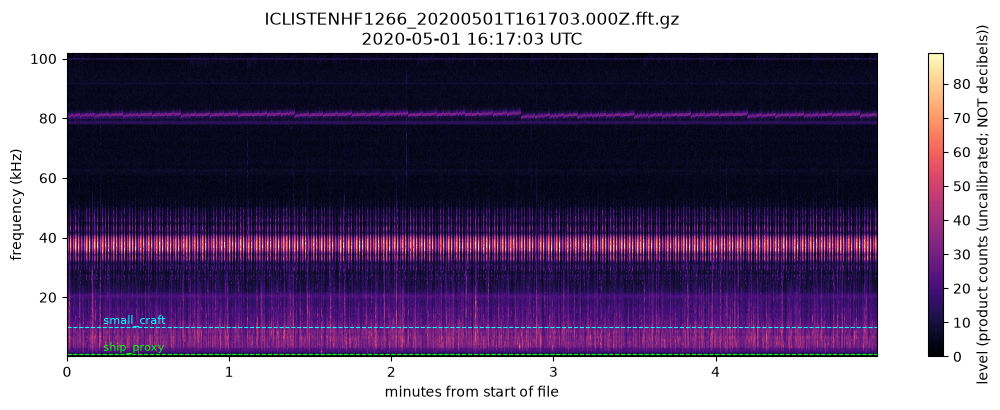

In [12]:
# One five-minute spectrogram. Time on the horizontal axis, frequency vertical,
# colour = level in product counts.
CEILING_BIN = config.FFT_ROLLOFF_ONSET_BIN   # 408; above this is filter roll-off, not ocean

fig, ax = plt.subplots(figsize=(11, 4.2))
img = ax.pcolormesh(
    (t_utc_s - t_utc_s[0]) / 60.0,            # minutes into the file, for readability
    freq_hz[1:CEILING_BIN] / 1000.0,          # kHz, skipping the structural zero at bin 0
    levels[:, 1:CEILING_BIN].T,
    shading="auto", cmap="magma",
)
ax.set_xlabel("minutes from start of file")
ax.set_ylabel("frequency (kHz)")
ax.set_title(f"{sample_path.name}\n{start_utc:%Y-%m-%d %H:%M:%S} UTC")
fig.colorbar(img, ax=ax, label=f"level ({config.FFT_LEVEL_UNIT})")

# Mark the two detection bands so the later plots are readable.
for (lo, hi), name, colour in [(config.FFT_B5_SMALL_CRAFT_BAND_HZ, "small_craft", "cyan"),
                               (config.FFT_B5_SHIP_PROXY_BAND_HZ, "ship_proxy", "lime")]:
    ax.axhline(lo / 1000, color=colour, lw=0.8, ls="--")
    ax.axhline(hi / 1000, color=colour, lw=0.8, ls="--")
    ax.text(0.2, hi / 1000, f" {name}", color=colour, va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

### The check that matters most: a synthetic tone

A pipeline that reports a plausible number is not the same as a pipeline that is right. Before
anything depended on this reader, we inserted a **tone of known loudness, at a known frequency,
at a known time** into a synthetic grid and demanded it come back out at that frequency and
that time. That is what `fft_io.assert_tone_at` enforces, and it is what proves the
time–frequency geometry rather than assuming it.

In [13]:
# Plant a tone at a known frequency and time in an otherwise flat grid, then demand
# the reader's own axes find it there. If the axis convention were wrong -- an
# off-by-one bin, or a time axis counting from zero -- this raises.
TONE_HZ, TONE_AT_S, TONE_LEVEL = 5_000.0, 120.0, 60

synthetic = np.zeros((config.FFT_N_FRAMES, config.FFT_N_BINS), dtype=np.int16)
tone_bin = int(round(TONE_HZ / config.FFT_BIN_WIDTH_HZ))
tone_frame = int(round(TONE_AT_S / config.FFT_FRAME_SECONDS))
synthetic[tone_frame:tone_frame + 8, tone_bin] = TONE_LEVEL

# The axes are the REAL ones the reader builds, not hand-made copies -- that is
# what makes this a test of the axis convention rather than of arithmetic.
t0 = start_utc.timestamp()
synthetic_t_utc_s = fft_io.time_axis_utc_s(t0)

fft_io.assert_tone_at(
    synthetic,
    freq_hz,                                  # the real frequency axis
    synthetic_t_utc_s,                        # absolute UTC seconds
    expected_freq_hz=TONE_HZ,
    expected_t_utc_s=t0 + TONE_AT_S,
    expected_level_db=TONE_LEVEL,             # "db" is the historical field name; counts
    level_tol_db=0.5,
)
print(f"PASS: a {TONE_LEVEL}-count tone planted at {TONE_HZ:,.0f} Hz and "
      f"{TONE_AT_S:.0f} s came back out at that frequency, that time and that level.")
print("     (tolerances are one frequency bin and one frame -- the finest the grid resolves)")

# And the counter-test: claim it is 1 kHz away, and the check must FAIL.
try:
    fft_io.assert_tone_at(synthetic, freq_hz, synthetic_t_utc_s,
                          expected_freq_hz=TONE_HZ + 1_000.0,
                          expected_t_utc_s=t0 + TONE_AT_S)
except fft_io.ToneMismatchError as exc:
    print(f"\nPASS: a deliberately wrong claim was rejected -- {type(exc).__name__}")
else:
    raise AssertionError("the tone check accepted a wrong frequency; it is not checking")

PASS: a 60-count tone planted at 5,000 Hz and 120 s came back out at that frequency, that time and that level.
     (tolerances are one frequency bin and one frame -- the finest the grid resolves)

PASS: a deliberately wrong claim was rejected -- ToneMismatchError


---
# 7. Step five — from a spectrum to a loudness trace

**Library module:** `boatphone/features.py`.

A boat passing the hydrophone is loud across a wide range of frequencies at once. So we
collapse the 512 frequency bins down to **one number per frame**: the level inside a chosen
band. `features.band_level_series(product, band_hz)` does exactly that, and returns a
`BandLevelSeries` that **carries the band it was computed over**, so two levels can never be
compared unless they came from the same function over the same band.

**The statistic is a median across the bins in the band, not a mean.** Deliberately: the median
cannot be moved by one loud bin. The echosounder ping at 37.65 kHz is a single bin, and a mean
would let a piece of ship equipment masquerade as a boat.

**"Ambient" is measured per window, not assumed.** The baseline is a low percentile (the 10th)
of the window's own levels — the quiet floor that this window sat on. Excess over ambient is
then what a boat contributes.

band                (1000.0, 10000.0) Hz
statistic           median_of_product_db
frames              1200
ambient (10th pct)  25.0 product counts (uncalibrated; NOT decibels)
peak                45.0
peak above ambient  20.0 counts


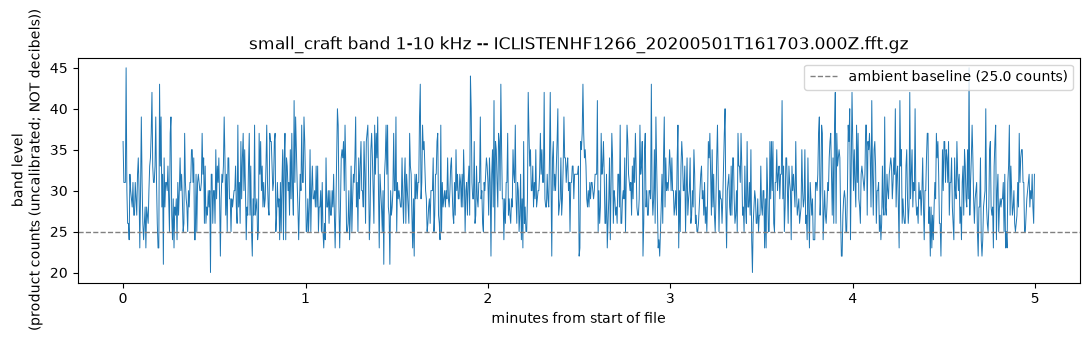

In [14]:
from boatphone import features

series = features.band_level_series(product, config.FFT_B5_SMALL_CRAFT_BAND_HZ)
band_level = np.asarray(series.level_counts)
ambient = features.ambient_baseline_counts(band_level)

print(f"band                {series.band_hz} Hz")
print(f"statistic           {config.FFT_BAND_LEVEL_STATISTIC}")
print(f"frames              {band_level.size}")
print(f"ambient (10th pct)  {ambient:.1f} {config.FFT_LEVEL_UNIT}")
print(f"peak                {band_level.max():.1f}")
print(f"peak above ambient  {band_level.max() - ambient:.1f} counts")

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot((t_utc_s - t_utc_s[0]) / 60.0, band_level, lw=0.7, color="tab:blue")
ax.axhline(ambient, color="grey", ls="--", lw=1,
           label=f"ambient baseline ({ambient:.1f} counts)")
ax.set_xlabel("minutes from start of file")
ax.set_ylabel(f"band level\n({config.FFT_LEVEL_UNIT})")
ax.set_title(f"small_craft band {config.FFT_B5_SMALL_CRAFT_BAND_HZ[0]/1000:.0f}"
             f"-{config.FFT_B5_SMALL_CRAFT_BAND_HZ[1]/1000:.0f} kHz -- {sample_path.name}")
ax.legend(); plt.tight_layout(); plt.show()

---
# 8. Step six — the viability gate: is this product usable at all?

**Program:** `scripts/run_b5_gate.py`

This step exists because of a plan change worth recording. The project originally intended to
run a **pretrained neural network** released by ONC over these spectrograms. That path was
tested and **rejected** (`docs/decisions/0012-b0-model-viability-outcome.md`), for four
independent reasons, any one of the last two sufficient on its own:

1. the CNN baseline the plan assumed does not exist in that repository;
2. the only released checkpoint has a **single binary output**, with engine noise pooled among
   eight anomaly types — there is no engine-noise output to read, and there are zero engine-noise
   examples for our exact device in its evaluation set anyway;
3. the forward pass runs out of memory under this container's real 3.90 GB limit;
4. scoring the corpus once would cost about **12 CPU-days**, regardless of hardware.

So the primary detector is **band-level loudness**, which needs no model weights at all — and
which is, in the end, the more defensible choice, because every step of it is inspectable.

The gate answers one question and no other: **does this product carry usable vessel-presence
structure?** It rests on four pieces of evidence that need no labels:

- **A.** The surface reads and reduces without degeneracy, and level clipping is low enough
  that a median is unbiased.
- **B.** Band level versus time shows **closest-point-of-approach structure** — a contiguous
  rise and fall as a boat approaches and departs — not isolated single-frame spikes.
- **C.** A **synthetic tone** of known level, frequency and time is recovered (section 6).
- **D.** The **nulls behave** — see below.

**Verdict: GO** (`docs/decisions/0027`).

### The nulls, and why they are not optional

A clean correlation between boats and acoustic energy is exactly what a time-alignment bug also
produces. So every count travels with two controls:

| Null | What it changes | What it tests |
|---|---|---|
| **frame shuffle** | frames put in random order | preserves the loudness distribution exactly, destroys only time order. A count that survives it was never about a passage. |
| **time shift** | a real window one hour away, same day | controls for "this hydrophone was simply noisy today". |

An empty cell in a null column means the null **could not be evaluated** (no data at the
shifted time). That is not the same as zero and is never counted as one.

In [15]:
# The gate over a handful of windows. Full run is longer; --max-windows keeps it quick.
run_script(["scripts/run_b5_gate.py", "--max-windows", "3"], heavy=True, timeout=1800)

SKIPPED (set RUN_HEAVY = True to run this):
    python3 scripts/run_b5_gate.py --max-windows 3


---
# 9. Step seven — the whole-corpus pass, and the population figures

**Programs:** `scripts/build_population_set.py`, then `scripts/plot_population_set.py`
**Output:** `data/derived/population/<run id>/`

One streaming pass over **all 26,666 windows** — not a sample. Decoding is the entire cost, so
everything is accumulated in a single decode per file:

- an **exact per-bin integer histogram** per season. The levels are small integers, so this is
  not a binned approximation of the distribution — it *is* the distribution, at 1-count
  resolution. Every percentile downstream is read straight off the cumulative histogram, with
  no quantile interpolation anywhere;
- a **per-window median spectrum** (this is the long-term spectrogram);
- **per-window levels in all four bands**;
- **per-window quality fields** — so data-quality claims are population claims too.

Nothing is padded, filled or truncated. A file that fails to decode is **counted and named**,
never skipped silently.

*Why not just use a sample?* An earlier methods brief established these figures on 180 windows
(30 per season). That is 0.7% of the corpus, and its sampling error was the same size as the
effects being discussed — the brief's own seasonal spread moved from 8.5 counts to 4.0 counts
when the sample grew from 8 to 40 files per season. A sample is the right way to argue that a
method is worth having and the wrong way to publish a population statistic.

### The three figures

| File | What it shows |
|---|---|
| `P1_ltsa_population.png` | **LTSA** — long-term spectrogram: frequency against calendar time across six summers |
| `P2_spd_population.png` | **SPD** — how often each level occurred at each frequency |
| `P3_seasonal_spectra_population.png` | median spectrum per season, with the detection bands marked |

In [16]:
run_script(["scripts/build_population_set.py"], heavy=True)       # tens of minutes
run_script(["scripts/plot_population_set.py"], heavy=True)        # seconds, once the above ran

SKIPPED (set RUN_HEAVY = True to run this):
    python3 scripts/build_population_set.py
SKIPPED (set RUN_HEAVY = True to run this):
    python3 scripts/plot_population_set.py


1 population run(s); showing the most recent: 20260827T211104Z



   absolute path: /home/jovyan/ohw26_proj_BoatPhone/data/derived/population/20260827T211104Z


file,size
P1_ltsa_population.png,182 kB
P2_spd_population.png,104 kB
P3_seasonal_spectra_population.png,193 kB
population.npz,"5,054 kB"
provenance.json,1 kB
seasonal_ambient.npz,5 kB
windows.json,"14,633 kB"


P1_ltsa_population.png


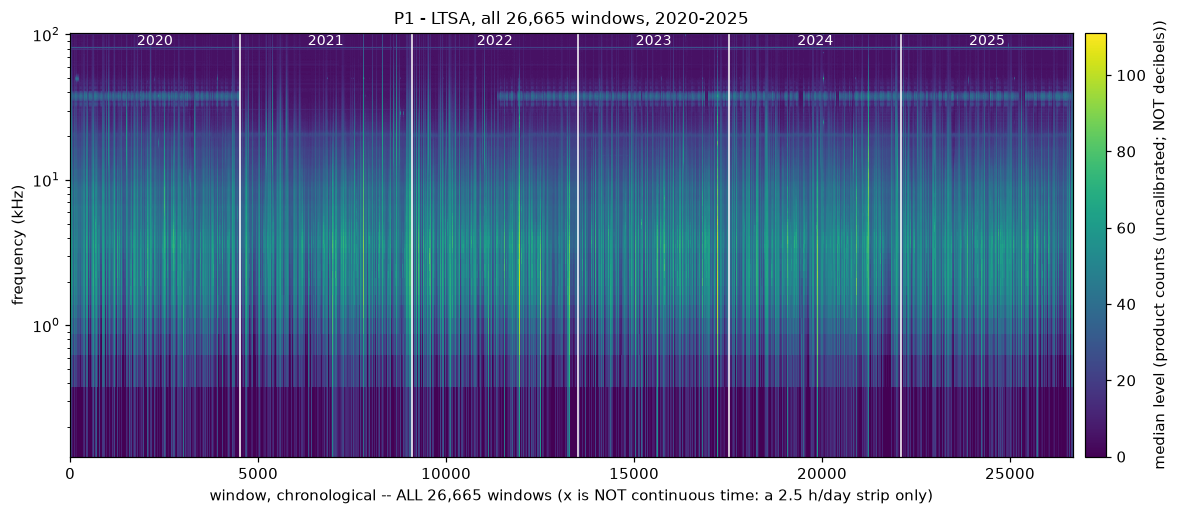

P2_spd_population.png


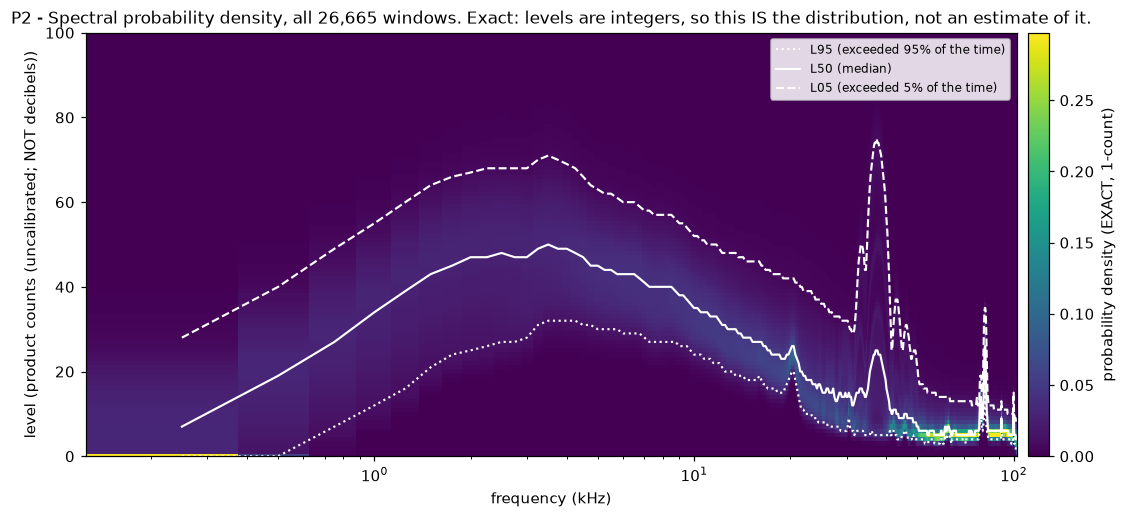

P3_seasonal_spectra_population.png


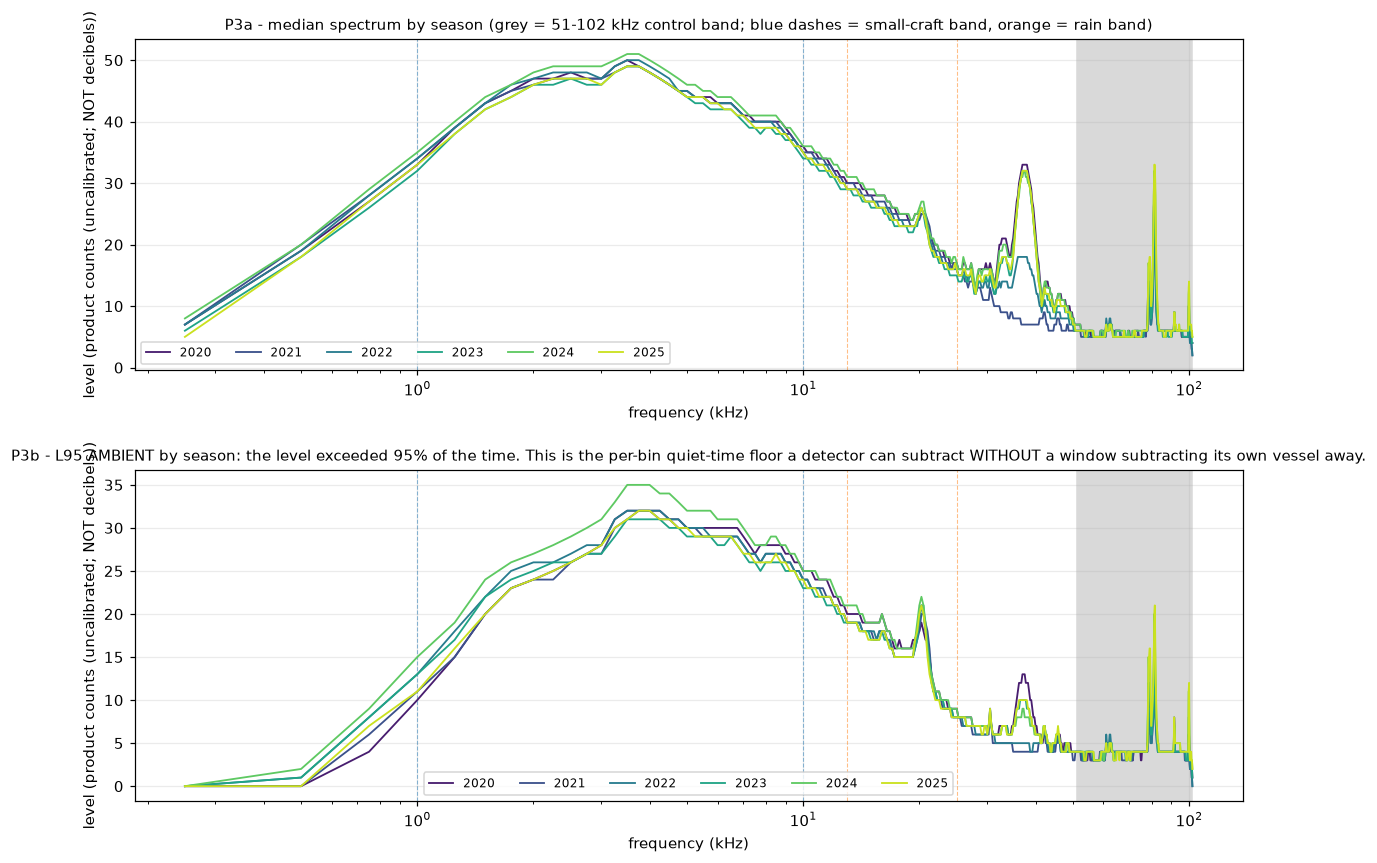

In [17]:
# Show the population figures already on disk, and link the folder holding them.
pop_root = paths.DERIVED_DIR / "population"
runs = sorted(p for p in pop_root.glob("*") if p.is_dir()) if pop_root.exists() else []
if not runs:
    print(f"No population run under {pop_root} -- run the two cells above with RUN_HEAVY = True.")
else:
    latest = runs[-1]
    print(f"{len(runs)} population run(s); showing the most recent: {latest.name}\n")
    show_folder(latest, f"data/derived/population/{latest.name}/  -- every file this run wrote")

    rows = "".join(
        f"<tr><td>{link(f)}</td><td style='text-align:right'>{f.stat().st_size/1024:,.0f} kB</td></tr>"
        for f in sorted(latest.iterdir()) if f.is_file()
    )
    display(HTML("<table><tr><th align='left'>file</th><th>size</th></tr>" + rows + "</table>"))

    for png in sorted(latest.glob("*.png")):
        print(png.name)
        display(Image(filename=str(png)))

    if len(runs) > 1:
        print("\nEarlier runs (kept; never overwritten):")
        for r in runs[:-1]:
            show_folder(r, r.name)

---
# 10. Step eight — the review sheets, for comparing sound against imagery

**Program:** `scripts/build_review_set.py` → `data/derived/review/<run id>/`

**All 30 window folders are linked in the table two cells below** — one row per
satellite pass, with a link to the folder and to each figure inside it.

One folder per satellite pass, holding the acoustic evidence for that window plus an **empty
slot for the satellite image**, so that a person can put the two side by side and say whether
they agree. Each window folder contains:

| File | What it is |
|---|---|
| `acoustics.png` | band levels over the window, with detections marked |
| `band_detail.png` | the rise-and-fall shape through closest approach |
| `denoised.png`, `denoised_labeled.png` | the spectrogram with the seasonal ambient removed |
| `spectra.png` | percentile spectra for the window |
| `planet_scene/` | **the empty slot the optical notebook fills** |
| `summary.json` | every number in the figures, in machine-readable form |

**Silent windows are included, and that is not optional.** Comparing detections against imagery
fills a 2×2 table: detector fired or stayed silent, crossed with boat present or absent. A
folder containing only detections can fill the top row alone, which yields "how often was I
right when I fired" — which is neither a false-positive rate nor a detection rate, and neither
of the two numbers the project needs. So every fully covered window is rendered, including the
ones where nothing was found, and the 12 scenes with **no acoustic coverage at all** appear in
the manifest as explicit absences rather than being quietly dropped.

**`planet_scene/` is now filled**, by `scripts/attach_planet_previews.py`, which copies each
scene's search-time RGB tile preview from the shared Planet delivery into its window folder:

```bash
python3 scripts/attach_planet_previews.py --dry-run   # say what would be copied
python3 scripts/attach_planet_previews.py
```

Each copy lands as `planet_scene/scene_preview.jpg` — the **same filename in every folder**,
which is what lets one script render the acoustic board and the optical board on the same grid
— beside a `provenance.json` recording the source path, its SHA-256, and the caveat below.

**A preview is for looking, not for measuring.** These are 8-bit, resampled to ~3.15 m/px and
JPEG-compressed, so nothing radiometric survives them. No threshold, no reflectance and no
detection may be computed from one; measurement runs on the analytic bundles
(`ortho_analytic_4b` / `_sr`) instead.

**All 30 windows have a preview**, which is more than have delivered imagery: 30 previews exist
against 26 ordered scenes, because previews cost tile quota rather than imagery quota and were
built for the whole gate-2 survivor set. Three of the four extras are validation timestamps we
hold manual vessel counts for but no delivered scene — so for those, **the preview is the only
picture that exists**.

> 🛰️ **OPTICAL HANDOFF — the detection overlay is still missing.**
> The slot holds the *scene*, not the *detections*. When the optical notebook can draw its
> boxes on a scene, that overlay belongs in the same folder beside `scene_preview.jpg`.

*Licensing note:* the source is licensed Planet imagery living in `shared-public`, which every
account on this hub can read. Keep it inside the hackweek; do not republish it.

In [18]:
run_script(["scripts/build_review_set.py", "--max-windows", "4"], heavy=True, timeout=3600)

SKIPPED (set RUN_HEAVY = True to run this):
    python3 scripts/build_review_set.py --max-windows 4


4 review run(s); showing the most recent: 20260828T042208Z
30 window folders



   absolute path: /home/jovyan/ohw26_proj_BoatPhone/data/derived/review/20260828T042208Z/windows



   absolute path: /home/jovyan/ohw26_proj_BoatPhone/data/derived/review/20260828T042208Z


window folder,coverage,figures,planet_scene/
20200730_192942_71_1059,full,acoustics · band_detail · denoised · denoised_labeled · spectra · summary.json,3 file(s)
20200806_183328_89_2206,full,acoustics · band_detail · denoised · denoised_labeled · spectra · summary.json,3 file(s)
20210601_191849_05_2412,full,acoustics · band_detail · denoised · denoised_labeled · spectra · summary.json,3 file(s)
20210616_183111_05_2448,full,acoustics · band_detail · denoised · denoised_labeled · spectra · summary.json,3 file(s)
20210616_183140_94_2436,full,acoustics · band_detail · denoised · denoised_labeled · spectra · summary.json,3 file(s)
20210626_182926_29_2457,full,acoustics · band_detail · denoised · denoised_labeled · spectra · summary.json,3 file(s)
20210730_182659_13_2434,full,acoustics · band_detail · denoised · denoised_labeled · spectra · summary.json,3 file(s)
20210812_191832_32_2406,full,acoustics · band_detail · denoised · denoised_labeled · spectra · summary.json,3 file(s)
20210812_194340_68_1058,full,acoustics · band_detail · denoised · denoised_labeled · spectra · summary.json,3 file(s)
20210824_181728_61_1067,full,acoustics · band_detail · denoised · denoised_labeled · spectra · summary.json,3 file(s)



Example sheet -- 20200730_192942_71_1059__full -- of the kind every link above opens:
acoustics.png


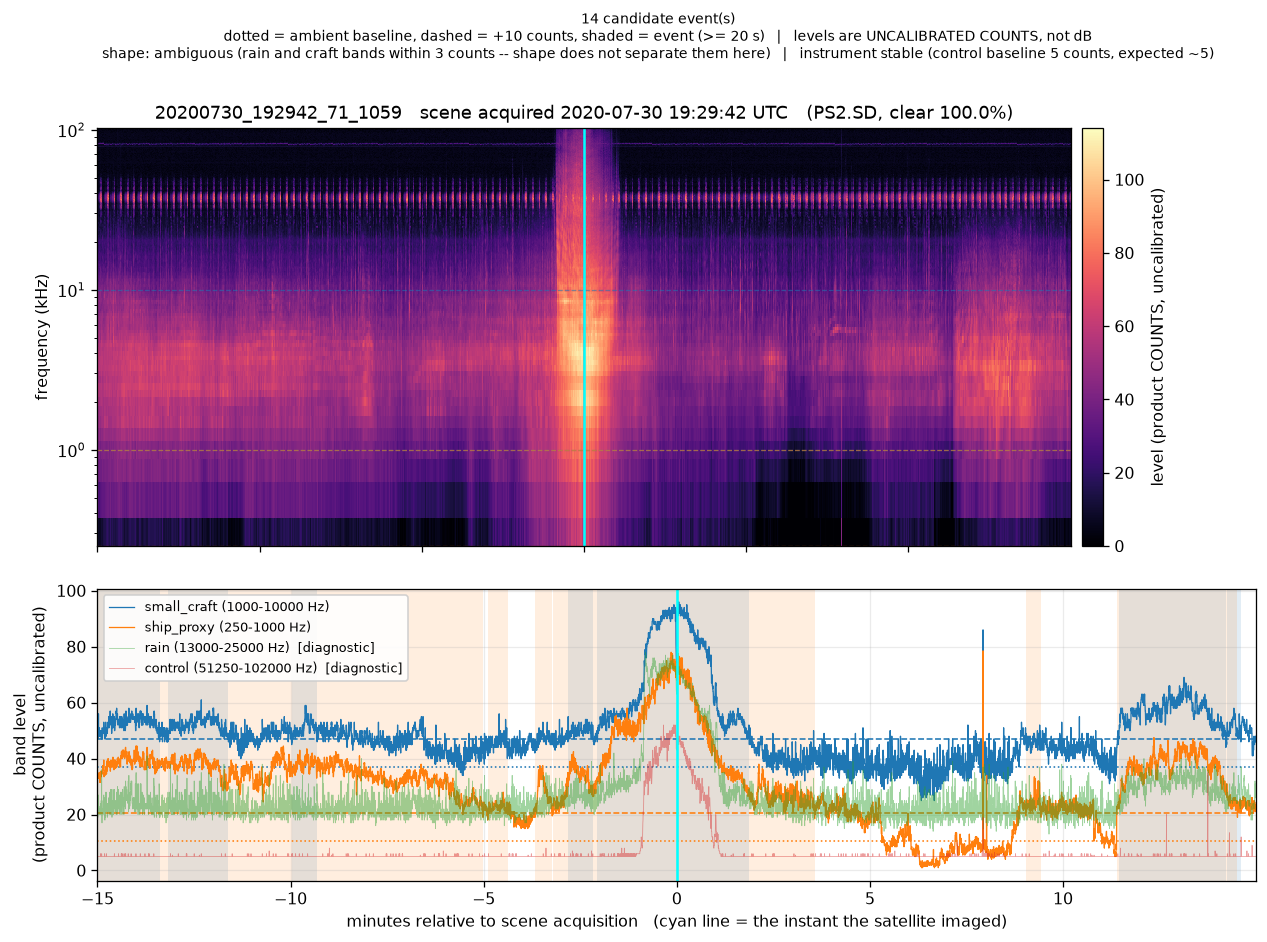

band_detail.png


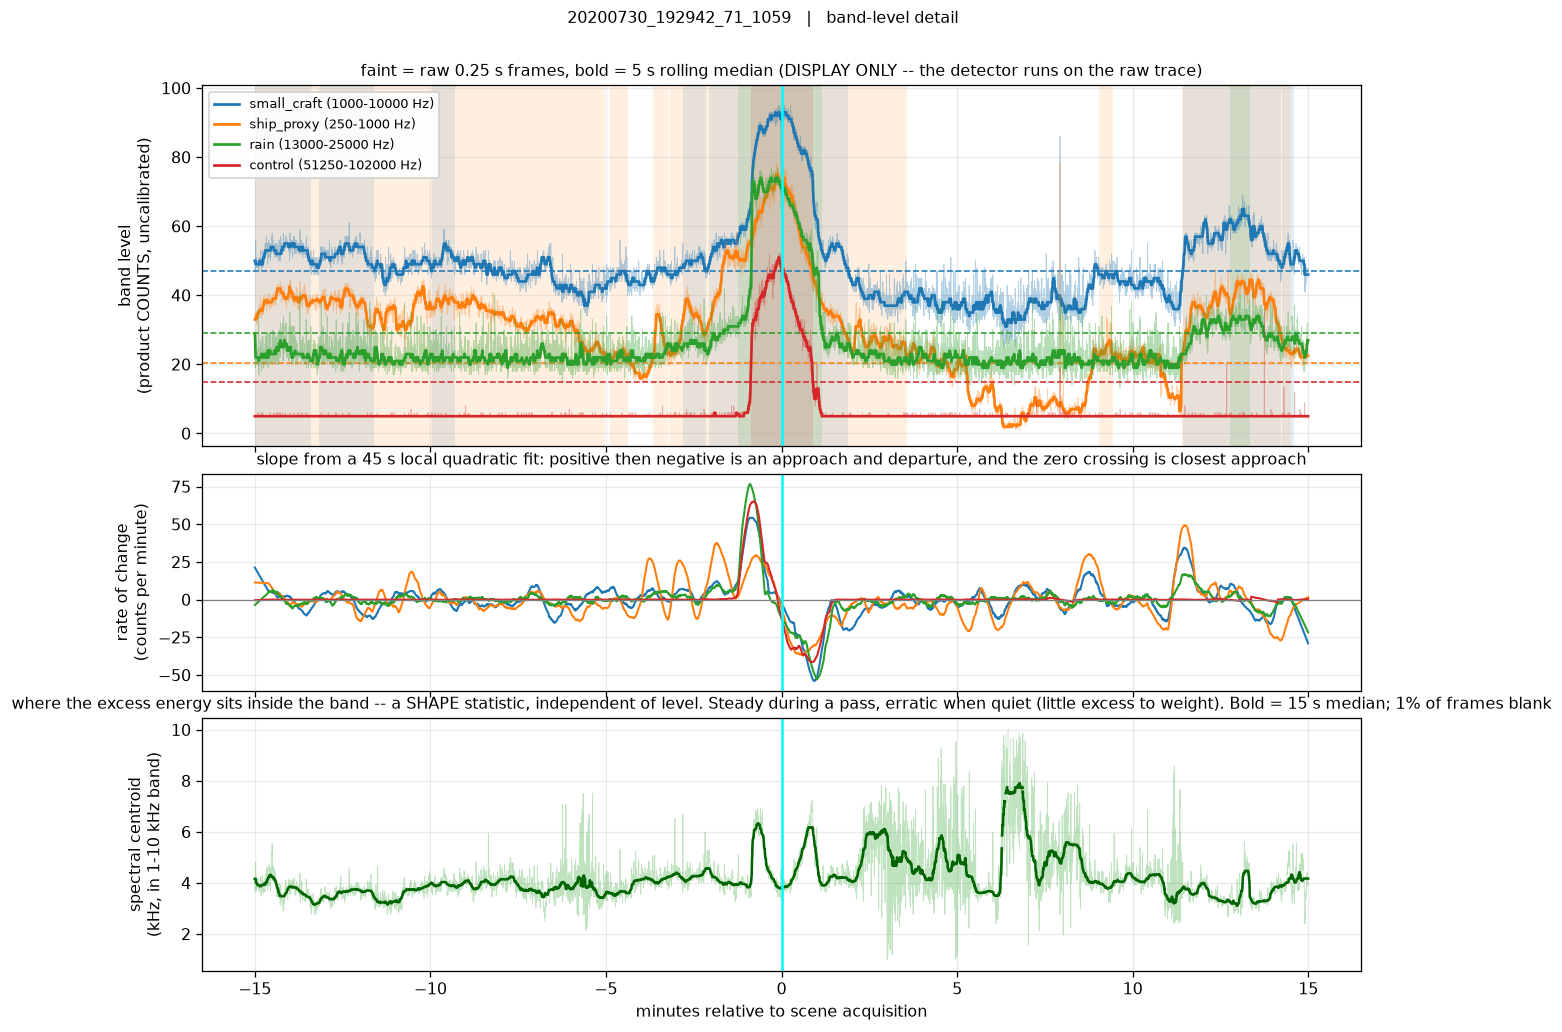


Earlier runs (kept; never overwritten):


   absolute path: /home/jovyan/ohw26_proj_BoatPhone/data/derived/review/20260827T215013Z


   absolute path: /home/jovyan/ohw26_proj_BoatPhone/data/derived/review/20260827T225501Z


   absolute path: /home/jovyan/ohw26_proj_BoatPhone/data/derived/review/20260828T013045Z


In [19]:
# EVERY review window, linked. Click a folder to see all of its figures at once, or a
# figure name to open just that one. One sheet is rendered inline underneath so the
# notebook still shows what a review sheet looks like when it is read as a document.
review_root = paths.DERIVED_DIR / "review"
runs = sorted(p for p in review_root.glob("*") if p.is_dir()) if review_root.exists() else []

if not runs:
    print(f"No review run under {review_root} -- run the cell above with RUN_HEAVY = True.")
else:
    latest = runs[-1]
    windows = sorted(p for p in (latest / "windows").glob("*") if p.is_dir())
    print(f"{len(runs)} review run(s); showing the most recent: {latest.name}")
    print(f"{len(windows)} window folders\n")

    show_folder(latest / "windows", f"ALL {len(windows)} WINDOW FOLDERS -- start here")
    print()
    show_folder(latest, "the run folder (README.md, detections.csv, provenance.json)")

    # One row per satellite pass. The figure list is built from what each window
    # ACTUALLY holds, which is not the same set everywhere -- a window with no
    # detection has no labelled denoising panel, and showing that is the point.
    FIG_ORDER = ["acoustics.png", "band_detail.png", "denoised.png",
                 "denoised_labeled.png", "spectra.png", "summary.json"]
    rows = []
    for w in windows:
        present = [f for f in FIG_ORDER if (w / f).exists()]
        figs = " &middot; ".join(link(w / f, f.replace(".png", "")) for f in present)
        scene = w.name.replace("__full", "").replace("__partial", "")
        coverage = w.name.split("__")[-1]
        planet = w / "planet_scene"
        n_planet = len(list(planet.iterdir())) if planet.is_dir() else 0
        planet_cell = (f"{n_planet} file(s)" if n_planet
                       else "<i>empty -- awaiting the optical notebook</i>")
        rows.append(f"<tr><td>{link(w, scene)}</td><td>{coverage}</td>"
                    f"<td>{figs}</td><td>{planet_cell}</td></tr>")
    display(HTML(
        "<table><tr><th align='left'>window folder</th><th>coverage</th>"
        "<th align='left'>figures</th><th align='left'>planet_scene/</th></tr>"
        + "".join(rows) + "</table>"))

    example = windows[0]
    print(f"\nExample sheet -- {example.name} -- of the kind every link above opens:")
    for png in ["acoustics.png", "band_detail.png"]:
        if (example / png).exists():
            print(png)
            display(Image(filename=str(example / png)))

    if len(runs) > 1:
        print("\nEarlier runs (kept; never overwritten):")
        for r in runs[:-1]:
            show_folder(r, r.name)

### All windows on one board — twice, on the same grid

**Program:** `scripts/build_review_contact_sheet.py`, run once per panel type:

| Board | Command | Output |
|---|---|---|
| **acoustic** | `--panel denoised_labeled.png` (the default) | `denoised_labeled_contact_sheet.png` |
| **optical** | `--panel planet_scene/scene_preview.jpg` | `planet_preview_contact_sheet.jpg` |

**One script, two boards, and that is the point.** Same grid, same chronological order, same
captions — so **cell 17 of one board is the same overpass as cell 17 of the other**, and the
two can be read side by side. Two separate scripts would drift apart within a day.

Both are **6 across and 5 down, chronological, left to right then top to bottom**, so a row is
roughly a season. The individual sheets are
right for judging one window against one image and wrong for seeing the corpus; side by side
the panels answer questions no single sheet can — whether the quiet windows cluster in a
season, whether the estimator's misses look different from its hits.

Each panel is captioned with its acquisition instant, its scene id, and both counts: **boats
counted by eye** and **boats estimated from sound**.

**There are 30 panels, not 29, and that is not an error.** There are 29 labelled *instants*
but 30 *scenes*: `20210616_183111` and `20210616_183140` are 29 seconds apart, so one manual
count covers both. Both scenes have their own acoustic window and their own figure, so both
are drawn and the pair is captioned `[label shared]`. Dropping one would discard a real
acoustic window; merging them would invent a count.

The acoustic board is ~16 MB at 180 dpi and the optical one ~3 MB at 200 dpi — both sized to
be zoomed into, since the axis text inside each acoustic panel is meant to stay readable. The
notebook shows a **low-resolution JPEG preview** of each for layout only, and links the real
files. **Never read a level off a preview.**

In [20]:
# Rebuild both boards. Each takes well under a minute, but they need the review set
# (and, for the optical board, the attached previews), so they sit with the heavy steps.
run_script(["scripts/build_review_contact_sheet.py"], heavy=True, timeout=1800)

review_runs = sorted(p for p in (paths.DERIVED_DIR / "review").glob("*") if p.is_dir())
if review_runs:
    run_script(["scripts/build_review_contact_sheet.py",
                "--panel", "planet_scene/scene_preview.jpg",
                "--out", review_runs[-1] / "planet_preview_contact_sheet.jpg",
                "--dpi", "200"], heavy=True, timeout=1800)

SKIPPED (set RUN_HEAVY = True to run this):
    python3 scripts/build_review_contact_sheet.py


SKIPPED (set RUN_HEAVY = True to run this):
    python3 scripts/build_review_contact_sheet.py --panel planet_scene/scene_preview.jpg --out /home/jovyan/ohw26_proj_BoatPhone/data/derived/review/20260828T042208Z/planet_preview_contact_sheet.jpg --dpi 200


ACOUSTIC -- denoised band spectrograms
30 panels, 5 rows x 6 columns, 180 dpi
reading order: chronological by acquisition instant, left to right, top to bottom


   absolute path: /home/jovyan/ohw26_proj_BoatPhone/data/derived/review/20260828T042208Z/denoised_labeled_contact_sheet.png

Layout preview -- ORIENTATION ONLY, do not read a level off it:


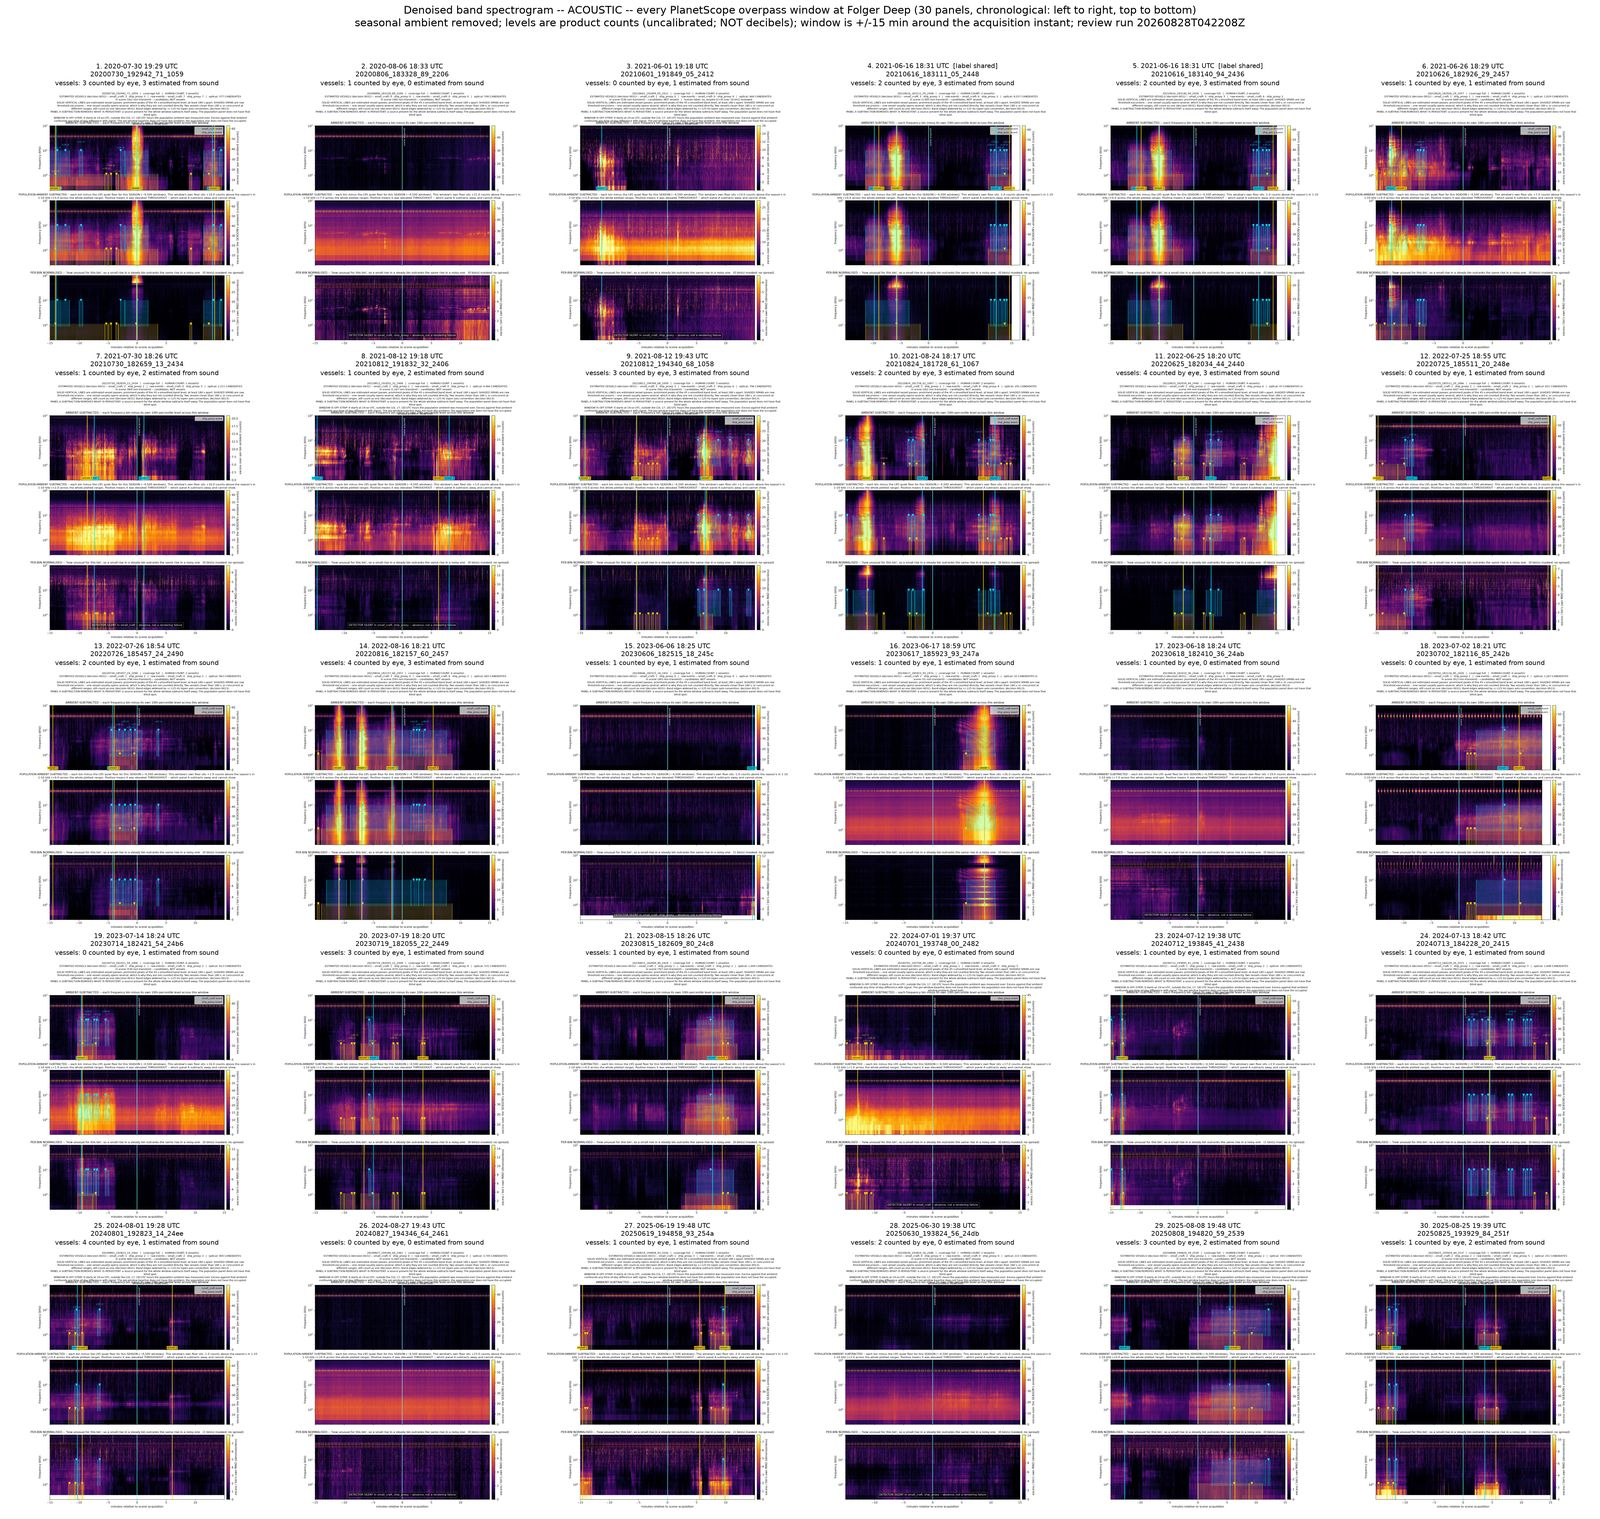


OPTICAL  -- PlanetScope tile previews
30 panels, 5 rows x 6 columns, 200 dpi
reading order: chronological by acquisition instant, left to right, top to bottom


   absolute path: /home/jovyan/ohw26_proj_BoatPhone/data/derived/review/20260828T042208Z/planet_preview_contact_sheet.jpg

Layout preview -- ORIENTATION ONLY, do not read a level off it:


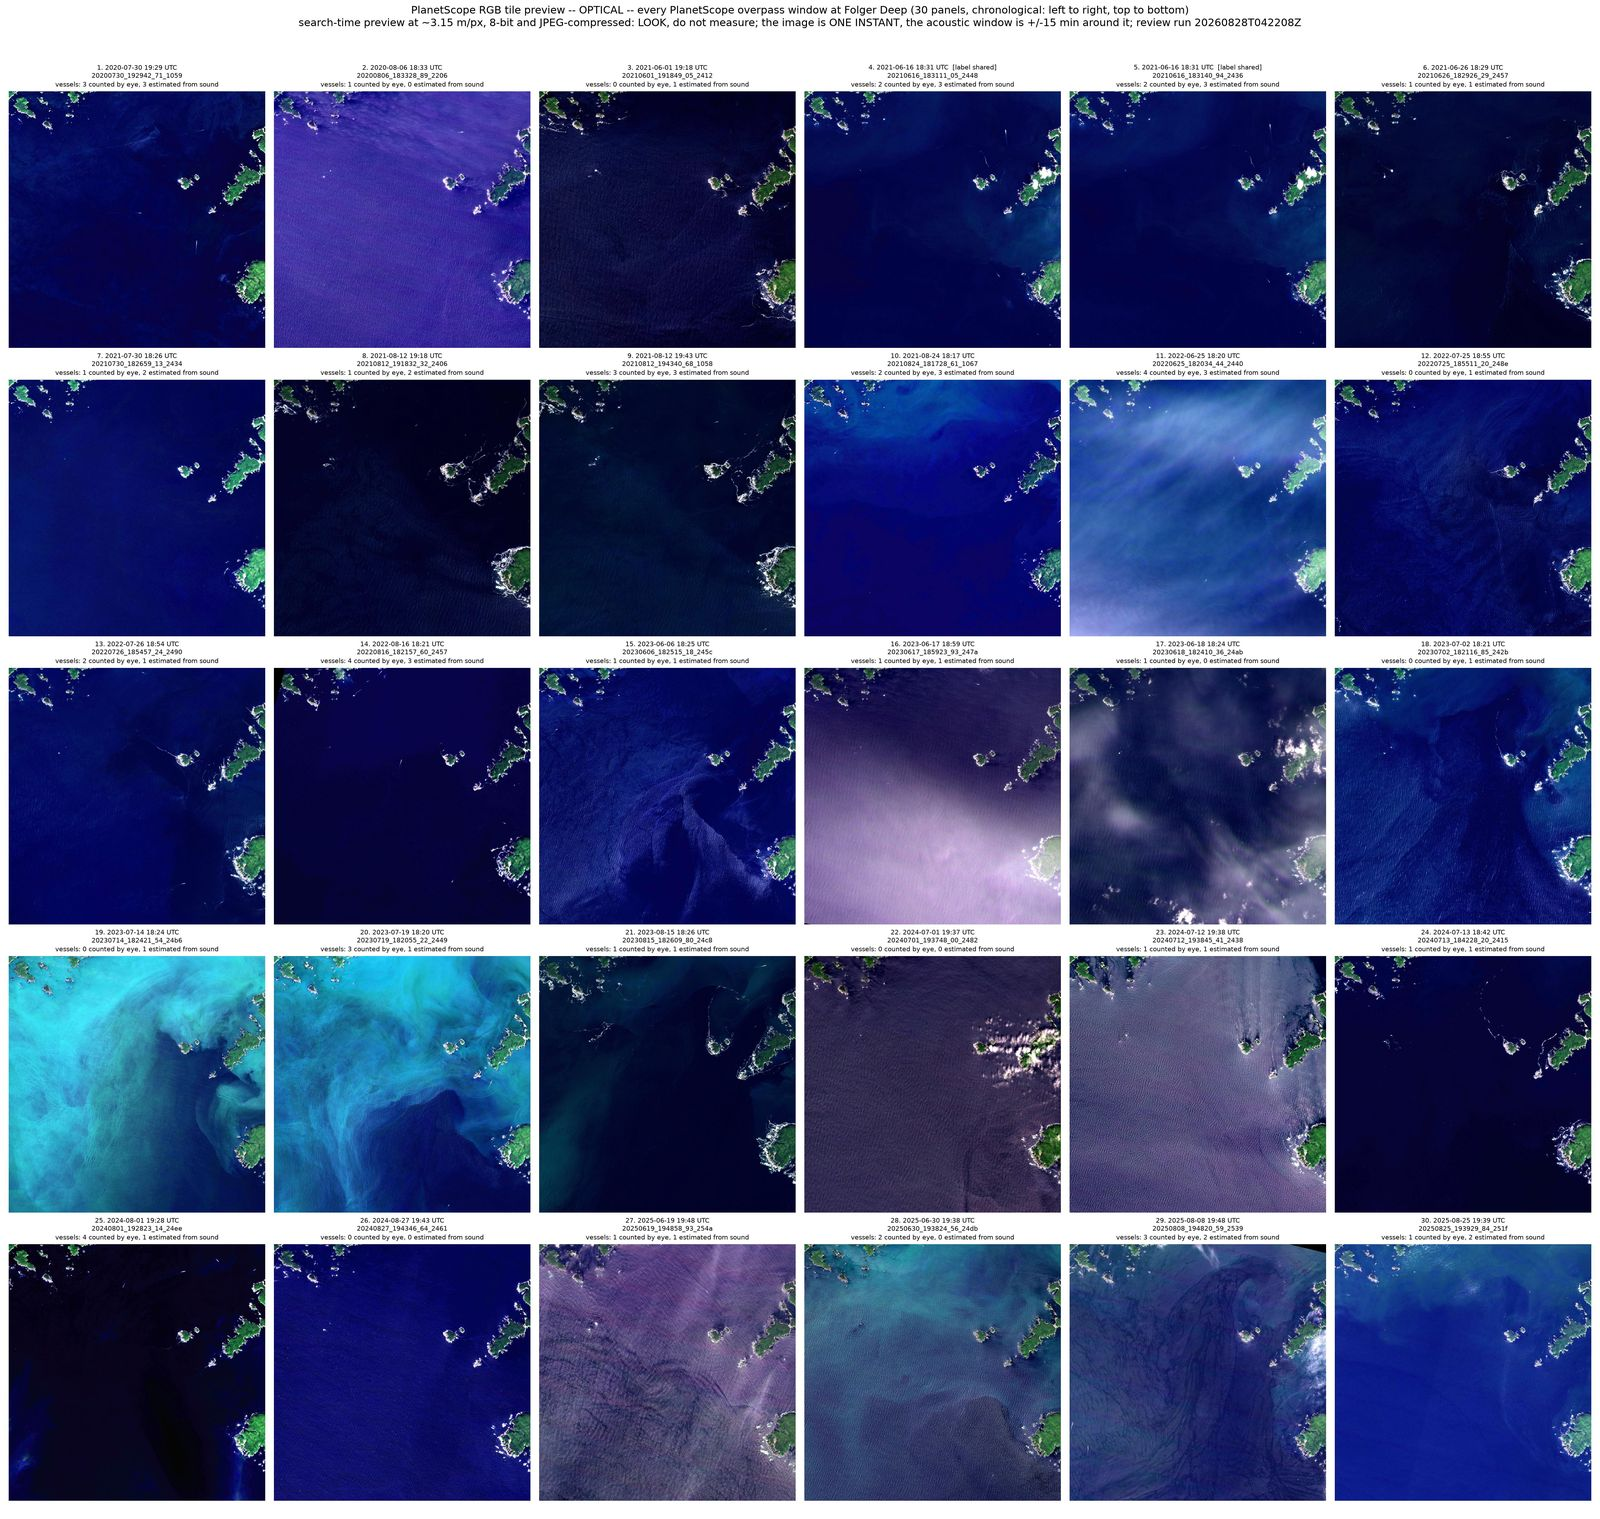

In [21]:
# Show both boards: a low-resolution preview inline, the real file linked.
review_root = paths.DERIVED_DIR / "review"
runs = sorted(p for p in review_root.glob("*") if p.is_dir()) if review_root.exists() else []

BOARDS = [("ACOUSTIC -- denoised band spectrograms", "denoised_labeled_contact_sheet.png"),
          ("OPTICAL  -- PlanetScope tile previews", "planet_preview_contact_sheet.jpg")]

for heading, filename in BOARDS:
    board = None
    for run in reversed(runs):                 # most recent run that actually has one
        if (run / filename).exists():
            board = run / filename
            break
    print("=" * 78)
    print(heading)
    print("=" * 78)
    if board is None:
        print(f"No {filename} yet -- run the cell above with RUN_HEAVY = True.\n")
        continue

    prov = json.loads(board.with_suffix(".provenance.json").read_text())
    print(f"{prov['n_panels']} panels, {prov['grid_rows']} rows x "
          f"{prov['grid_columns']} columns, {prov['dpi']} dpi")
    print(f"reading order: {prov['reading_order']}")
    if prov["n_windows_without_panel"]:
        # A window with no panel is NAMED, so a short board can never look complete.
        print(f"windows with no panel and therefore NOT drawn: "
              f"{prov['windows_without_panel']}")
    display(HTML("&#128444; <b>full resolution ({:.0f} MB) -- open this one to read it:</b> {}"
                 .format(board.stat().st_size / 1e6, link(board, board.name))))
    print("   absolute path:", board.resolve())

    preview = board.with_name(board.stem + "_preview.jpg")
    if preview.exists():
        print("\nLayout preview -- ORIENTATION ONLY, do not read a level off it:")
        display(Image(filename=str(preview)))
    print()

---
# 11. Step nine — the ground truth: boats counted by eye

**Files:** `data/validation/planet_scope_validations.csv` — the 29 counts everything
downstream actually reads — and `data/labels/optical_vessel_labels.csv`, the richer schema
(which records *the area the reviewer examined*, plus who reviewed it and when) that new
labels should be written into. They are not yet merged, deliberately: the working file carries
no reviewed area, so a row moved across would silently acquire one it never had.

This is the only place a label lives. **The acoustic detector must never write here**, and
nothing here may be derived from acoustics — that independence is the entire reason a label is
worth anything. It is tracked in git, unlike everything else under `data/`, because the labels
are small, hand-authored, and by far the most expensive artefact in the project to reproduce.

The `area_km2` column matters more than it looks: it records **the area the reviewer actually
examined**, so a count can never be misread as a count over some other footprint.

**Current state: 29 labelled moments, 44 boats counted, six of them zero-boat windows.**

> 🛰️ **OPTICAL HANDOFF — more labels are the top priority.**
> 29 moments with six negatives cannot separate a real estimator from a lucky one. The next
> labelled batch is also what arbitrates between the two candidate counters in section 12. If
> the estimator's ratio moves far from 1.0 on that batch, it was fitted rather than measured.

In [22]:
# TWO label files exist, and they are not interchangeable.
#
#  data/validation/planet_scope_validations.csv  -- the WORKING count file. Two
#      columns, "timestamp" and "vessel count", 29 rows. This is what the events
#      table and the estimator comparison actually read.
#  data/labels/optical_vessel_labels.csv         -- the RICHER schema (label,
#      n_vessels, the area the reviewer examined, who reviewed it, when). It is
#      where labels should land from now on, and it currently holds one row.
#
# Merging them is a deliberate open item, not an oversight: the working file has
# no reviewed area, so a row moved across would silently acquire one it never had.

validation_csv = paths.DATA_DIR / "validation" / "planet_scope_validations.csv"
labels_csv = paths.REPO_ROOT / ov.OPTICAL_LABELS_RELPATH

if validation_csv.exists():
    rows = [r for r in csv.reader(validation_csv.open())][1:]
    counts = [(r[0].strip(), int(r[1])) for r in rows if len(r) >= 2 and r[1].strip()]
    total = sum(n for _, n in counts)
    zeros = sum(1 for _, n in counts if n == 0)
    print(f"{validation_csv.relative_to(paths.REPO_ROOT)}")
    print(f"  {len(counts)} labelled moments, {total} boats counted by eye, "
          f"{zeros} of them zero-boat windows\n")
    print("  timestamp        boats")
    for stamp, n in counts[:8]:
        print(f"  {stamp:16s}{n:5d}")
    print(f"  ... and {len(counts)-8} more")
else:
    print("no working label file at", validation_csv)

print()
if labels_csv.exists():
    rich = list(csv.DictReader(labels_csv.open()))
    print(f"{labels_csv.relative_to(paths.REPO_ROOT)}  ({len(rich)} row(s), richer schema)")
    print(f"  {'scene_id':34s}{'label':12s}{'n':>3s}  {'area_km2':>8s}  reviewer")
    for r in rich:
        print(f"  {r['scene_id']:34s}{r['label']:12s}{r['n_vessels'] or '-':>3s}"
              f"  {r['area_km2']:>8s}  {r['reviewer']}")
else:
    print("no rich label file at", labels_csv)

data/validation/planet_scope_validations.csv
  29 labelled moments, 44 boats counted by eye, 6 of them zero-boat windows

  timestamp        boats
  20200730_1929       3
  20200806_1833       1
  20210601_1918       0
  20210616_1831       2
  20210626_1829       1
  20210730_1826       1
  20210812_1918       1
  20210812_1943       3
  ... and 21 more

data/labels/optical_vessel_labels.csv  (1 row(s), richer schema)
  scene_id                          label         n  area_km2  reviewer
  20210601_191849_05_2412           no_vessels    0      10.0  Isaac Guld


---
# 12. Step ten — counting boats, and how the counter was chosen

**Programs:** `scripts/build_events_table.py` (production table),
`scripts/compare_event_grouping.py` (the estimator bake-off).
**Output:** `data/derived/events/<run id>/`

### The problem with the obvious method

The first counter looked for **excursions above a threshold**: stretches where the band level
sat more than 10 counts above the window's own ambient for at least 20 seconds. It gave 298
events against 44 counted boats. The reason is simple once seen: a boat's level *fluctuates*,
so every brief dip below the threshold ended one event and started another. One passage,
several "events". Merging fragments separated by ≤10 s cut it to 135, which helped and did not
fix it.

### What works instead: prominent peaks

A boat approaches, reaches its closest point, and departs. In a smoothed loudness trace that is
**one rise and one fall** — one peak — no matter how much the level wobbles on the way.

`run_b5_gate.estimate_vessel_count()` therefore smooths the band level over **45 seconds** and
counts **prominent peaks** separated by at least **180 seconds**. *Prominence* — standing a full
threshold above its immediate surroundings, not above the window's baseline — is the property
that separates one wobbling boat from two boats.

### How it scored (29 labelled moments, 44 boats, ±15 min window, de-duplicated)

| estimator | predicted | ratio to truth | within ±1 | correlation *r* |
|---|---|---|---|---|
| **`estimate_vessel_count`** (production) | **40** | **0.91** | **26/29** | **+0.590** |
| peak prominence, half threshold | 48 | 1.09 | 26/29 | +0.611 |
| merged events (10 s gap) | 55 | 1.25 | 19/29 | +0.477 |
| presence only (fired / silent) | 24 | 0.55 | 21/29 | +0.262 |

It **replicates on the disjoint `ship_proxy` band** (ratio 1.07, r = +0.598), which is the
closest thing to an independent detector available without a second instrument.

### Why the honest claim is weaker than that table looks

- **The methods were pre-declared.** All 8 estimators × 4 window widths were written down
  *before* any of them was scored, and all 32 are reported. At n = 29 that is the only defence
  against choosing a winner by its score and then quoting that score — and it is a weak one.
- **The top two are a tie.** Production stays on the stricter one rather than churning for a
  coin-flip.
- **Two boats within 180 s count as one, by construction.** Both remaining misses were exactly
  this. A band-split union (counting peaks separately in 1–4 kHz and 4–10 kHz) recovers both,
  but its four parameters came from a post-hoc sweep of 36 configurations, so it is **not
  adopted** — it is the candidate the next labelled batch should arbitrate.
- **The window stays at ±15 minutes.** Shorter is measurably worse: at ±5 min the best ratio is
  0.43. Boats audible near the satellite pass are not all within five minutes of it.

### Two bugs and one cleared worry, all worth keeping

- **The clipping bug.** `concat_window` returns whole 5-minute *files*, so a 1800-second window
  arrived as up to 2100 seconds and every statistic covered ~17% more time than its label
  claimed. `build_events_table` now clips to the window and prints how many frames it dropped.
  Unclipped, the estimator reads 51 instead of 42.
- **The duplication bug** — section 5, and the reason `analysis_file_index()` exists.
- **The loudness worry is cleared.** A frame shuffle preserves each window's level
  *distribution*, so it cannot probe *between-window* loudness differences — the wrong
  diagnostic. The right one is partial correlation against each window's median level:
  r = +0.581 against r = +0.590. Removing loudness costs 0.009. **The estimator is not simply
  reading which windows were loud.**

### And one thing that is still not established

**The time-shift null does not collapse.** A window an hour away from the satellite pass yields
37 passages against 42 at the pass. We count passages well; we have **not** shown they are the
satellite's boats. `docs/decisions/0030` stands.

In [23]:
run_script(["scripts/build_events_table.py"], heavy=True, timeout=7200)
run_script(["scripts/compare_event_grouping.py", "--band", "small_craft"],
           heavy=True, timeout=7200)

SKIPPED (set RUN_HEAVY = True to run this):
    python3 scripts/build_events_table.py
SKIPPED (set RUN_HEAVY = True to run this):
    python3 scripts/compare_event_grouping.py --band small_craft


In [24]:
# Read the most recent events table already on disk.
events_root = paths.DERIVED_DIR / "events"
runs = sorted(p for p in events_root.glob("*") if p.is_dir()) if events_root.exists() else []
if not runs:
    print(f"No events run under {events_root} -- run the cell above with RUN_HEAVY = True.")
else:
    latest = runs[-1]
    print(f"{len(runs)} events run(s); showing the most recent: {latest.name}\n")
    show_folder(latest, f"data/derived/events/{latest.name}/")
    display(HTML("&#128196; " + " &middot; ".join(
        link(f) for f in sorted(latest.iterdir()) if f.is_file())))
    print()
    wide = list(csv.DictReader((latest / "events_by_window_wide.csv").open()))
    hdr = (f"{'scene':34s}{'manual':>7s}{'estimated':>10s}"
           f"{'events(merged)':>16s}{'coverage':>10s}")
    print(hdr); print("-" * len(hdr))
    tot_manual = tot_est = 0
    for r in wide:
        manual = r["manual_vessel_count"]
        est = r["n_small_craft_vessels_est"]
        print(f"{r['scene_id']:34s}{manual or '-':>7s}{est or '-':>10s}"
              f"{r['n_small_craft_merged']:>16s}{r['coverage']:>10s}")
        if manual: tot_manual += int(manual)
        if manual and est: tot_est += int(est)
    print("-" * len(hdr))
    print(f"{'TOTAL over labelled windows':34s}{tot_manual:>7d}{tot_est:>10d}")

11 events run(s); showing the most recent: 20260828T034753Z



   absolute path: /home/jovyan/ohw26_proj_BoatPhone/data/derived/events/20260828T034753Z



scene                              manual estimated  events(merged)  coverage
-----------------------------------------------------------------------------
20200730_192942_71_1059                 3         3               5      full
20200806_183328_89_2206                 1         0               0      full
20210601_191849_05_2412                 0         1               0      full
20210616_183111_05_2448                 2         3               4      full
20210616_183140_94_2436                 2         3               4      full
20210626_182926_29_2457                 1         1               2      full
20210730_182659_13_2434                 1         2               0      full
20210812_191832_32_2406                 1         2               0      full
20210812_194340_68_1058                 3         3               4      full
20210824_181728_61_1067                 2         3               5      full
20220625_182034_44_2440                 4         3            

In [25]:
# The narrative summary the same run writes -- the totals, the 2x2 table against the
# manual counts, and the merge-gap sensitivity sweep.
if runs:
    print((runs[-1] / "events_by_window_summary.md").read_text()[:6000])

# Acoustic events across all overpass windows -- 20260828T034753Z

Produced by `scripts/build_events_table.py`. Per-row detail in `events_by_window.csv`.

## Totals by band

Counts shown as `raw -> merged` (merge gap 10 s). **The merge rule is applied identically to the real events and to BOTH nulls** -- merging only the real side would drop that count while the nulls held, inventing a difference out of bookkeeping.

| band | detection? | windows scored | events | frame-shuffled | time-shifted (-1 h) |
|---|---|---|---|---|---|
| `control` | diagnostic | 30 | 6 -> **6** | 0 -> 0 | 3 -> 3 (n=30 windows) |
| `rain` | diagnostic | 30 | 19 -> **16** | 0 -> 0 | 21 -> 17 (n=30 windows) |
| `ship_proxy` | yes | 30 | 89 -> **63** | 0 -> 0 | 85 -> 66 (n=30 windows) |
| `small_craft` | yes | 30 | 82 -> **59** | 0 -> 0 | 101 -> 71 (n=30 windows) |

**Detection bands together: n = 171 raw events -> **122 merged** across 30 overpasses**, against 0 under the frame-shuffle null.

## Against the manua

### One phrase that keeps being misread

**`small_craft` and `ship_proxy` are FREQUENCY BANDS, not boat classes.** The same detector runs
over both, and a broadband passage appears in each. Band membership is **not** a size
classification. Telling small boats from large ones acoustically is project goal G2, and it is
unanswered.

### Two negative results, kept so nobody re-spends the time

- **Splitting into 4 bands gives identical numbers to 2 bands, every time.** The 10–25 kHz and
  25–51 kHz bands never pass the qualification gate. Absorption-driven separation by range — a
  near boat lighting up the high bands where a far one cannot — **does not operate** at the
  ranges present in this data. Only the 1–4 / 4–10 kHz split carries information.
- **DEMON (blade-rate demodulation) is impossible here**, not merely hard — see section 5.

---
# 13. The checks

There is **no pytest, no linter and no type checker** in this environment, so the checks are
plain assert-based functions in one file. They are the closest thing the project has to a test
suite, and several of them were written *before* the code they check, which is the point: a
check that has never failed has not been shown to check anything.

```bash
python3 scripts/checks.py
```

**Current state: 183 passed, 0 failed, 4 skipped.** The four skips are network checks, which
run only when `BOATPHONE_ALLOW_NETWORK` is set; a skip is reported as *not verified*, never as
a pass.

The strongest verification available beyond that is re-executing a notebook top to bottom in a
fresh kernel.

In [26]:
run_script(["scripts/checks.py"], heavy=True, timeout=3600)

SKIPPED (set RUN_HEAVY = True to run this):
    python3 scripts/checks.py


---
# 14. Reproduce everything, in order

Copy-paste from a shell at the repository root. Sections in brackets refer to this notebook.

```bash
# --- once -------------------------------------------------------------------
cp .env.example .env          # then paste your ONC token into it          [1]
python3 -m boatphone.env_audit                # what is installed, what is missing
python3 scripts/checks.py                     # 183 passed, 0 failed, 4 skipped [13]

# --- acquisition (hours; ~7 GB; needs the token) ----------------------------
python3 scripts/build_uptime_calendar.py --dry-run                            # [3]
python3 scripts/build_uptime_calendar.py
python3 scripts/pull_overpass_corpus.py --dry-run                             # [5.1]
python3 scripts/pull_overpass_corpus.py
python3 scripts/pull_labelled_windows.py --scene <scene_id>                   # [5.2]

# --- analysis and figures (minutes to tens of minutes; no network) ----------
python3 scripts/run_b5_gate.py                                                # [8]
python3 scripts/build_population_set.py                                       # [9]
python3 scripts/plot_population_set.py
python3 scripts/build_review_set.py                                           # [10]
python3 scripts/attach_planet_previews.py          # fills planet_scene/ from shared-public
python3 scripts/build_review_contact_sheet.py                      # the acoustic board
python3 scripts/build_review_contact_sheet.py \\
    --panel planet_scene/scene_preview.jpg --dpi 200               # the optical board
python3 scripts/build_events_table.py                                         # [12]
python3 scripts/compare_event_grouping.py --band small_craft
```

Every one of these writes a `provenance.json` beside its output recording the git commit, the
inputs and the parameters that produced it. If a figure and a number ever disagree, that file
is where the disagreement is resolved.

### Environment

The analysis runs on the shared Oceanhackweek JupyterHub (`/home/.pixi/envs/default`,
Python 3.14). `environment.yml` in the repository root is a **portable floor** for running
off-hub, not a re-creation of the hub, and it says so in its own header. Two honest notes: the
acoustic path needs only `numpy`, `scipy`, `matplotlib` and the `onc` client; the optical path
additionally needs `rasterio`, `opencv`, `ultralytics` and `huggingface_hub`, and `rasterio` is
**not** on the hub — it needs `pip install --user rasterio`.

---
# 15. Open items, and everything the optical notebook owes this one

### 🛰️ Optical handoff flags, collected

| # | Section | What is needed |
|---|---|---|
| 1 | 3 | **Order archive imagery for 2020–2025 only.** The deployment ended 2026-03-14, so a 2026 scene has no acoustic counterpart at all. Avoid the four outages in `docs/derived/hydrophone_gaps.md`. |
| 2 | 4 | **Confirm the hydrophone coordinate.** `optical.HYDROPHONE_LONLAT` is the AOI centre, not device metadata; a claimed ONC coordinate is 272 m away, which is a 32% range error at 0.84 km. ONC records position **per deployment**, so one coordinate cannot cover six years. Run `getDeployments(deviceCode="ICLISTENHF1266")` with a token. |
| 3 | 10 | ~~Fill `planet_scene/`~~ **DONE** — `scripts/attach_planet_previews.py` puts each scene's RGB tile preview in its window folder, all 30. **Still outstanding: the detection overlay**, which belongs beside `scene_preview.jpg` once the optical notebook can draw its boxes. |
| 4 | 11 | **More labels.** The single highest-value thing anyone can do for this pipeline. |
| 5 | 12 | Labels are also what **arbitrates** `estimate_vessel_count` against the band-split union counter. |
| 6 | — | **Import the study window from `boatphone/config.py`.** A known drift exists: an acquisition notebook restated the season as June–September instead of `SEASON_MONTHS_UTC = (5,6,7,8,9)`, so roughly a third of the in-season candidate pool was never searched. |
| 7 | — | **`detections.csv` is candidates, not vessels.** 32,877 rows over 26 scenes, one scene contributing 8,257. The optical detector's per-scene count is driven by sea-surface texture rather than by boats, so nothing here treats those rows as a vessel count. |

### Still open on the acoustic side

1. **The time-shift null does not collapse** (`docs/decisions/0030`). This is the most important
   unresolved item in the pipeline. Until it does, we can say we count boat passages well; we
   cannot say they are the satellite's boats.
2. **Vessel *size* from sound (goal G2) is unanswered.** Bands are not classes.
3. **Detection range (goal G3) is unmeasured**, which is why the "false positives" in section 12
   cannot be read as false positives: the acoustic window is ±15 minutes and the hydrophone
   probably hears well beyond the image footprint, so an empty scene can be acoustically
   occupied with no error by either instrument.
4. **Concurrent boats.** Two vessels within 180 s are one peak by construction. The band-split
   union is the candidate fix, awaiting labels.

### Where to read further

| Document | What it settles |
|---|---|
| `docs/plans/Project_Source_of_Truth.txt` | the authoritative running record — read it first, it changes daily |
| `docs/decisions/0002-time-alignment-and-units.md` | the time and unit conventions, and why they are enforced |
| `docs/decisions/0012-b0-model-viability-outcome.md` | why the pretrained model path was abandoned |
| `docs/decisions/0027-...` | why the `.fft.gz` product is viable, and uncalibrated |
| `docs/decisions/0030-time-shift-null-does-not-collapse.md` | the open null |
| `docs/decisions/0031-vessel-count-is-prominent-peaks-...md` | why counting changed |
| `docs/plans/acoustics_plan_v2.md` | the current acoustics plan |

### A closing note on method

Four habits are responsible for most of what this pipeline got right, and they cost very
little to adopt:

1. **Prove the pipeline against a synthetic signal of known level, frequency and time** before
   anything depends on it.
2. **Be suspicious of a result that works.** A clean correlation between boats and acoustic
   energy is exactly what a time-alignment bug also produces. Check against a null, and report
   that you did.
3. **Let errors surface.** No bare `except`, no filling across a real recording gap, no
   truncating to fix a length mismatch. Each of those turns a data problem into a plausible
   number. If you drop samples, print how many.
4. **Distinguish "the method found nothing" from "the method is broken."** Only the second is a
   bug, and they need different follow-ups. Say which one you are looking at.